Imports and Setup

In [ ]:
import torch
import sys
import torch
print(sys.executable)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


c:\Users\akmfo\torch_gpu\venv\Scripts\python.exe
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
!pip install tensorflow gensim -q
! pip install wordcloud -q


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
from collections import Counter

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk. stem import WordNetLemmatizer, PorterStemmer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras. layers import (Dense, Embedding, SimpleRNN, LSTM, GRU,
                                      Dropout, Bidirectional, GlobalAveragePooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow. keras.preprocessing.sequence import pad_sequences
from tensorflow.keras. utils import to_categorical
from tensorflow.keras. callbacks import EarlyStopping

#WordCloud
from wordcloud import WordCloud

# Gensim for Word2Vec/Skip-gram
from gensim.models import Word2Vec

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random. set_seed(42)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\akmfo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\akmfo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\akmfo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\akmfo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Load Dataset

In [ ]:
train_file = r"C:\Users\akmfo\Downloads\Question Answer Classification Dataset 7.csv"
test_file = r"C:\Users\akmfo\Downloads\[Updated] Question Answer Classification Dataset[Test].csv"

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)


print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")

Training set shape: (93333, 2)
Testing set shape: (59999, 2)


Exploratory Data Analysis (EDA)

In [ ]:
# Basic Dataset Information
print("\nTraining Dataset Info")
train_info_df = pd.DataFrame({
    'Column': train_df. columns,
    'Non-Null Count': [train_df[col].notna().sum() for col in train_df.columns],
    'Null Count': [train_df[col]. isna().sum() for col in train_df.columns],
    'Dtype': [train_df[col].dtype for col in train_df.columns]
})
display(train_info_df)

print("\nFirst 5 rows of Training Data")
display(train_df. head())

print("\nTesting Dataset Info")
test_info_df = pd.DataFrame({
    'Column':  test_df.columns,
    'Non-Null Count':  [test_df[col].notna().sum() for col in test_df.columns],
    'Null Count': [test_df[col]. isna().sum() for col in test_df.columns],
    'Dtype':  [test_df[col].dtype for col in test_df. columns]
})
display(test_info_df)

print("\nFirst 5 rows of Testing Data")
display(test_df. head())


Training Dataset Info


,Column,Non-Null Count,Null Count,Dtype
0,QA Text,93333,0,object
1,Class,93333,0,object



First 5 rows of Training Data


,QA Text,Class
0,<html> Question Title:\n <br> what does it mea...,Family & Relationships
1,<html> Question Title:\n <br> A huge dam wall ...,Education & Reference
2,<html> Question Title:\n <br> in the broadway ...,Entertainment & Music
3,<html> Question Title:\n <br> Were people booi...,Sports
4,<html> Question Title:\n <br> Im trying to sav...,Computers & Internet



Testing Dataset Info


,Column,Non-Null Count,Null Count,Dtype
0,QA Text,59999,0,object
1,Class,59999,0,object



First 5 rows of Testing Data


,QA Text,Class
0,<html>\nQuestion Title:<br>Why does Zebras hav...,Science & Mathematics
1,<html>\nQuestion Title:<br>What did the itsy b...,Education & Reference
2,<html>\nQuestion Title:<br>What is the differe...,Education & Reference
3,<form>\nQuestion Title:<br>Why do women get PM...,Health
4,<html>\nQuestion Title:<br>If your co-worker i...,Health


In [ ]:
# Column Names
print("\nColumn Names")
columns_df = pd. DataFrame({
    'Dataset': ['Training', 'Testing'],
    'Columns': [train_df.columns. tolist(), test_df.columns.tolist()],
    'Number of Columns': [len(train_df.columns), len(test_df.columns)]
})
display(columns_df)


Column Names


,Dataset,Columns,Number of Columns
0,Training,"[QA Text, Class]",2
1,Testing,"[QA Text, Class]",2


In [ ]:
# Identify text and label columns
text_col = train_df.columns[0]
label_col = train_df. columns[1] if len(train_df.columns) > 1 else train_df.columns[0]

column_roles_df = pd.DataFrame({
    'Role': ['Text Column', 'Label Column'],
    'Column Name': [text_col, label_col]
})
print("\nIdentified Columns")
display(column_roles_df)


Identified Columns


,Role,Column Name
0,Text Column,QA Text
1,Label Column,Class


In [ ]:
# Check for Missing Values
print("\nMissing Values")
missing_values_df = pd. DataFrame({
    'Column': train_df.columns. tolist() + test_df. columns.tolist(),
    'Missing Count': train_df.isnull().sum().tolist() + test_df.isnull().sum().tolist(),
    'Dataset': ['Training'] * len(train_df. columns) + ['Testing'] * len(test_df.columns)
})
missing_pivot = missing_values_df.pivot(index='Column', columns='Dataset', values='Missing Count').fillna(0).astype(int)
display(missing_pivot)


Missing Values


Dataset,Testing,Training
Column,,
Class,0,0
QA Text,0,0


In [ ]:
# Class Distribution
print("\nClass Distribution (Training)")
class_dist = train_df[label_col].value_counts()
class_dist_df = pd.DataFrame({
    'Class': class_dist. index,
    'Count': class_dist.values,
    'Percentage (%)': (class_dist.values / class_dist.values.sum() * 100).round(2)
})
display(class_dist_df)



Class Distribution (Training)


,Class,Count,Percentage (%)
0,Family & Relationships,9455,10.13
1,Politics & Government,9425,10.10
2,Business & Finance,9393,10.06
3,Entertainment & Music,9386,10.06
4,Society & Culture,9304,9.97
5,Sports,9299,9.96
6,Computers & Internet,9298,9.96
7,Science & Mathematics,9296,9.96
8,Health,9286,9.95
9,Education & Reference,9191,9.85


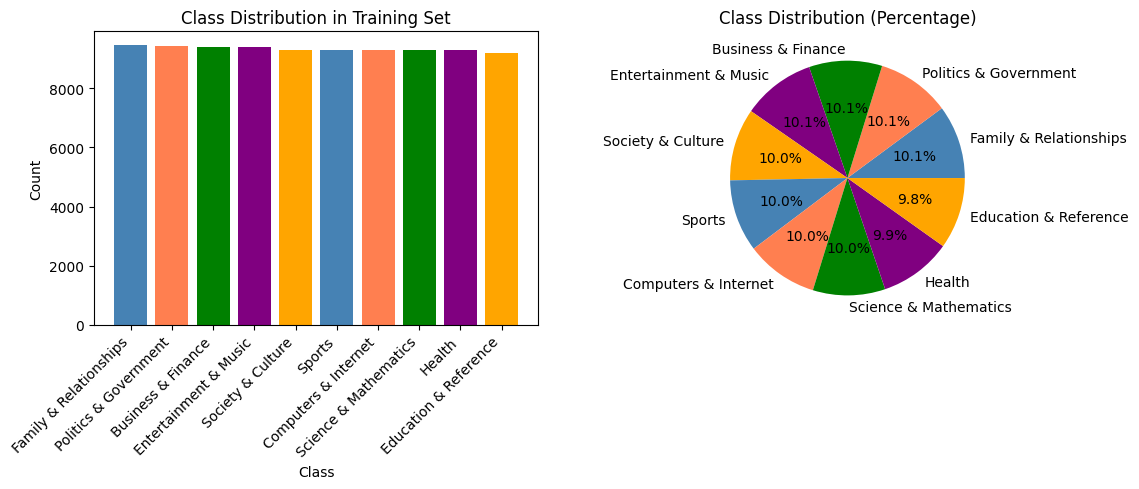

In [ ]:
# Visualize class distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = ['steelblue', 'coral', 'green', 'purple', 'orange'][: len(class_dist)]
plt.bar(class_dist_df['Class']. astype(str), class_dist_df['Count'], color=colors)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.pie(class_dist_df['Count'], labels=class_dist_df['Class'], autopct='%1.1f%%', colors=colors)
plt.title('Class Distribution (Percentage)')
plt.tight_layout()
plt.show()

In [ ]:
# Text Length Analysis
train_df['text_length'] = train_df[text_col].astype(str).apply(len)
train_df['word_count'] = train_df[text_col].astype(str).apply(lambda x: len(x.split()))

print("\nText Length Statistics")
text_stats_df = train_df[['text_length', 'word_count']]. describe().T
text_stats_df = text_stats_df.round(2)
display(text_stats_df)


Text Length Statistics


,count,mean,std,min,25%,50%,75%,max
text_length,93333.0,634.15,576.43,127.0,290.0,452.0,754.0,6413.0
word_count,93333.0,106.49,98.52,16.0,46.0,75.0,129.0,1041.0


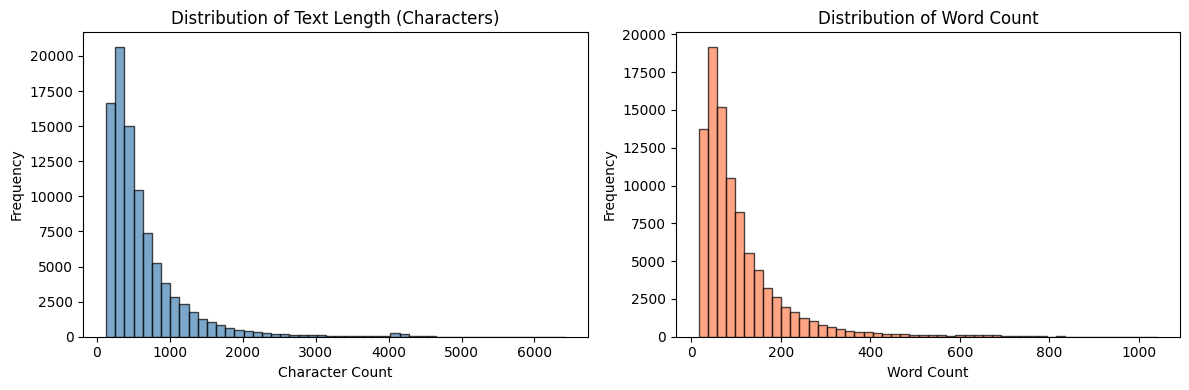

In [ ]:
# Visualize text length distribution
plt. figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(train_df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Text Length (Characters)')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(train_df['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

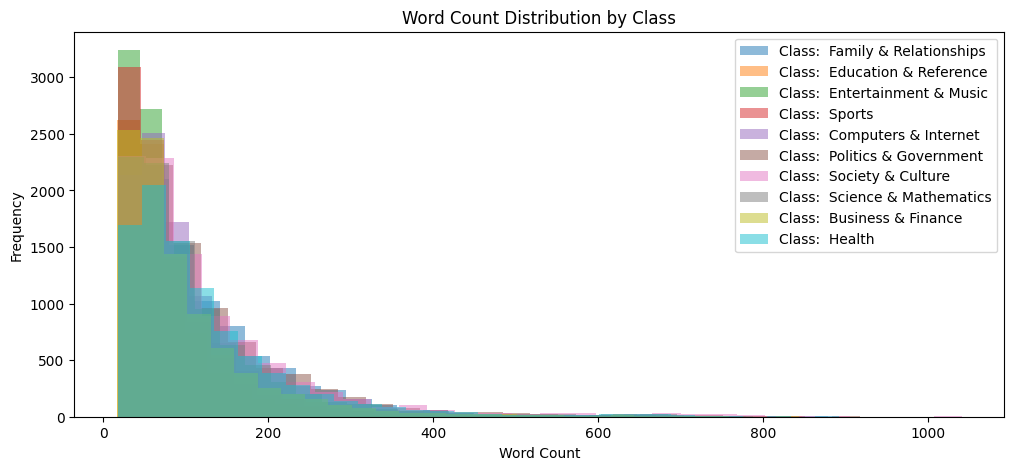

In [ ]:
# Text Length by Class
plt.figure(figsize=(12, 5))
for i, cls in enumerate(train_df[label_col].unique()):
    subset = train_df[train_df[label_col] == cls]['word_count']
    plt.hist(subset, bins=30, alpha=0.5, label=f'Class:  {cls}')
plt.title('Word Count Distribution by Class')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# Most Common Words (Before Preprocessing)
print("\nMost Common Words (Before Preprocessing)")
all_words = ' '.join(train_df[text_col].astype(str).tolist()).lower().split()
word_freq = Counter(all_words)
top_words_df = pd.DataFrame(word_freq. most_common(20), columns=['Word', 'Count'])
top_words_df['Rank'] = range(1, 21)
top_words_df = top_words_df[['Rank', 'Word', 'Count']]
display(top_words_df)


Most Common Words (Before Preprocessing)


,Rank,Word,Count
0,1,<br>,560001
1,2,the,355265
2,3,to,236248
3,4,and,201225
4,5,a,200064
5,6,question,191573
6,7,of,159454
7,8,i,156796
8,9,is,143901
9,10,you,138569



Word Cloud Visualization Before Preprocessing


Text(0.5, 1.0, 'Word Cloud - Before Preprocessing')

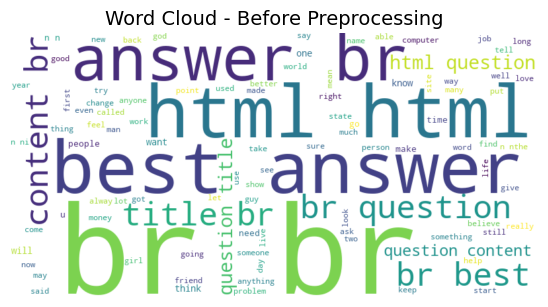

In [ ]:
# Word Cloud Visualization
print("\nWord Cloud Visualization Before Preprocessing")

# Word Cloud for entire training corpus (before preprocessing)
plt.figure(figsize=(15, 5))

# Before preprocessing
plt.subplot(1, 2, 1)
all_text_before = ' '.join(train_df[text_col].astype(str).tolist())
wordcloud_before = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_text_before. lower())
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Before Preprocessing', fontsize=14)

In [ ]:
# Sample Texts from Each Class
print("\nSample Texts from Each Class")
samples_list = []
for cls in train_df[label_col].unique():
    sample = train_df[train_df[label_col] == cls][text_col]. iloc[0]
    samples_list. append({
        'Class':  cls,
        'Sample Text (First 200 chars)': sample[:200] + '...'
    })
samples_df = pd. DataFrame(samples_list)
display(samples_df)


Sample Texts from Each Class


,Class,Sample Text (First 200 chars)
0,Family & Relationships,<html> Question Title:\n <br> what does it mea...
1,Education & Reference,<html> Question Title:\n <br> A huge dam wall ...
2,Entertainment & Music,<html> Question Title:\n <br> in the broadway ...
3,Sports,<html> Question Title:\n <br> Were people booi...
4,Computers & Internet,<html> Question Title:\n <br> Im trying to sav...
5,Politics & Government,<html> Question Title:\n <br> is there really ...
6,Society & Culture,<html> Question Title:\n <br> Does anyone thin...
7,Science & Mathematics,<html> Question Title:\n <br> What is hydroele...
8,Business & Finance,<html> Question Title:\n <br> how do i adertis...
9,Health,<html> Question Title:\n <br> Why is it when i...


Text Preprocessing

In [ ]:
# Initialize tools
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text, use_lemma=True, remove_stopwords=True):
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]

    # Lemmatization or Stemming
    if use_lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    else:
        tokens = [stemmer. stem(t) for t in tokens]

    # Remove short words
    tokens = [t for t in tokens if len(t) > 2]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing training data...")
train_df['cleaned_text'] = train_df[text_col]. apply(preprocess_text)
print("Training Preprocessing Completed.")

print("Preprocessing testing data...")
test_df['cleaned_text'] = test_df[text_col].apply(preprocess_text)
print("Testing Preprocessing Completed.")

Preprocessing training data...
Training Preprocessing Completed.
Preprocessing testing data...
Testing Preprocessing Completed.


EDA After Preprocessing

In [ ]:
# Show preprocessing results
print("\nPreprocessing Results:  Original vs Cleaned (Sample)")
preprocessing_samples_df = pd.DataFrame({
    'Index': range(3),
    'Original Text (First 150 chars)': [train_df[text_col].iloc[i][:150] + '...' for i in range(3)],
    'Cleaned Text (First 150 chars)': [train_df['cleaned_text'].iloc[i][:150] + '...' for i in range(3)]
})
display(preprocessing_samples_df)


Preprocessing Results:  Original vs Cleaned (Sample)


,Index,Original Text (First 150 chars),Cleaned Text (First 150 chars)
0,0,<html> Question Title:\n <br> what does it mea...,question title mean dream someone inlove quest...
1,1,<html> Question Title:\n <br> A huge dam wall ...,question title huge dam wall reservoir dam wal...
2,2,<html> Question Title:\n <br> in the broadway ...,question title broadway musical rent mean ever...


In [ ]:
# Post-preprocessing statistics
print("\nPost-Preprocessing Statistics")
train_df['cleaned_word_count'] = train_df['cleaned_text'].apply(lambda x: len(x. split()) if x else 0)

post_stats_df = train_df['cleaned_word_count'].describe().reset_index()
post_stats_df. columns = ['Statistic', 'Value']
post_stats_df['Value'] = post_stats_df['Value']. round(2)
display(post_stats_df)


Post-Preprocessing Statistics


,Statistic,Value
0,count,93333.00
1,mean,50.56
2,std,49.53
3,min,6.00
4,25%,21.00
5,50%,35.00
6,75%,61.00
7,max,565.00


In [ ]:
# Most common words after preprocessing
print("\nMost Common Words (After Preprocessing)")
all_cleaned_words = ' '. join(train_df['cleaned_text']. tolist()).split()
cleaned_word_freq = Counter(all_cleaned_words)

top_cleaned_words_df = pd.DataFrame(cleaned_word_freq.most_common(20), columns=['Word', 'Count'])
top_cleaned_words_df['Rank'] = range(1, 21)
top_cleaned_words_df = top_cleaned_words_df[['Rank', 'Word', 'Count']]
display(top_cleaned_words_df)


Most Common Words (After Preprocessing)


,Rank,Word,Count
0,1,question,196904
1,2,best,103256
2,3,answer,102460
3,4,title,94147
4,5,content,94034
5,6,get,31411
6,7,like,30624
7,8,one,27406
8,9,would,27124
9,10,know,26682



Word Cloud Visualization After Preprocessing


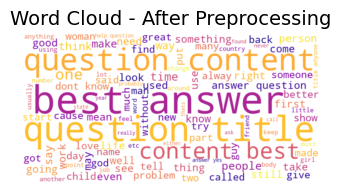

In [ ]:
 # Word Cloud After preprocessing
print("\nWord Cloud Visualization After Preprocessing")
plt.subplot(1, 2, 2)
all_text_after = ' '.join(train_df['cleaned_text'].tolist())
wordcloud_after = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='plasma'
).generate(all_text_after)
plt.imshow(wordcloud_after, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - After Preprocessing', fontsize=14)

plt.tight_layout()
plt.show()


Word Cloud by Class


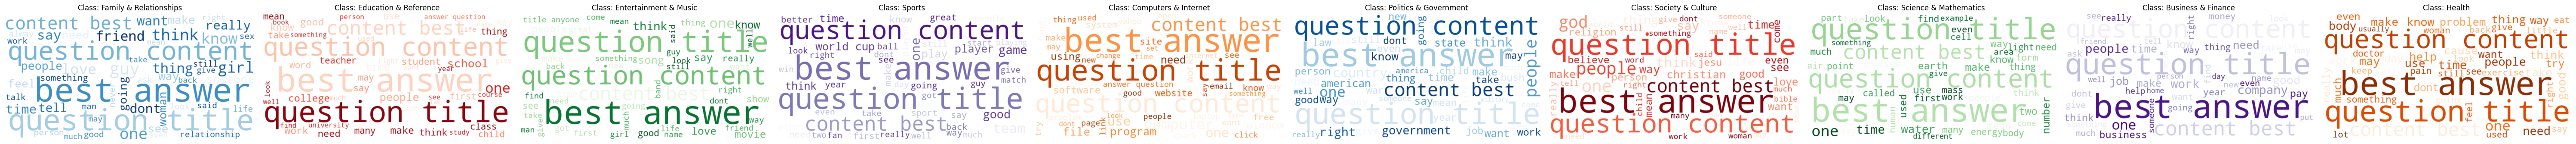

In [ ]:
# Word Cloud per class (after preprocessing)
print("\nWord Cloud by Class")
num_unique_classes = len(train_df[label_col]. unique())
fig, axes = plt.subplots(1, num_unique_classes, figsize=(6*num_unique_classes, 5))

if num_unique_classes == 1:
    axes = [axes]

colors_wc = ['Blues', 'Reds', 'Greens', 'Purples', 'Oranges']
for idx, cls in enumerate(train_df[label_col].unique()):
    class_text = ' '.join(train_df[train_df[label_col] == cls]['cleaned_text'].tolist())
    if class_text. strip():
        wc = WordCloud(
            width=800,
            height=400,
            background_color='white',
            max_words=50,
            colormap=colors_wc[idx % len(colors_wc)]
        ).generate(class_text)
        axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx]. axis('off')
    axes[idx]. set_title(f'Class: {cls}', fontsize=12)

plt.tight_layout()
plt.show()

Label Encoder

In [ ]:
# Encode labels
label_encoder = LabelEncoder()
train_df['encoded_label'] = label_encoder.fit_transform(train_df[label_col])
test_df['encoded_label'] = label_encoder.transform(test_df[label_col])

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

# Prepare data
X_train = train_df['cleaned_text'].values
y_train = train_df['encoded_label'].values
X_test = test_df['cleaned_text'].values
y_test = test_df['encoded_label'].values

# Create validation split from training data
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nTraining set size: {len(X_train_split)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Number of classes: 10
Classes: ['Business & Finance' 'Computers & Internet' 'Education & Reference'
 'Entertainment & Music' 'Family & Relationships' 'Health'
 'Politics & Government' 'Science & Mathematics' 'Society & Culture'
 'Sports']

Training set size: 74666
Validation set size: 18667
Test set size: 59999


TF-IDF Vectorization

In [ ]:
# TF-IDF Vectorizer with tuned parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_split)
X_val_tfidf = tfidf_vectorizer. transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Training shape: {X_train_tfidf. shape}")
print(f"TF-IDF Validation shape: {X_val_tfidf. shape}")
print(f"TF-IDF Test shape:  {X_test_tfidf.shape}")

TF-IDF Training shape: (74666, 10000)
TF-IDF Validation shape: (18667, 10000)
TF-IDF Test shape:  (59999, 10000)


Skipgram Embedding

In [ ]:
# Tokenize for Skip-gram
tokenized_texts = [text. split() for text in X_train]

# Train Skip-gram model
EMBEDDING_DIM = 100
skipgram_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    workers=4,
    sg=1  # Skip-gram
)

print(f"Skip-gram vocabulary size: {len(skipgram_model.wv)}")
print(f"Embedding dimension: {EMBEDDING_DIM}")

# Prepare sequences for neural networks
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_split)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nPadded sequence shape (Train): {X_train_pad.shape}")
print(f"Padded sequence shape (Val): {X_val_pad.shape}")
print(f"Padded sequence shape (Test): {X_test_pad. shape}")

# Create embedding matrix from Skip-gram
word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in word_index. items():
    if i < vocab_size:
        if word in skipgram_model.wv:
            embedding_matrix[i] = skipgram_model.wv[word]

print(f"Embedding matrix shape:  {embedding_matrix. shape}")

# One-hot encode labels for neural networks
y_train_cat = to_categorical(y_train_split, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

Skip-gram vocabulary size: 75084
Embedding dimension: 100

Padded sequence shape (Train): (74666, 100)
Padded sequence shape (Val): (18667, 100)
Padded sequence shape (Test): (59999, 100)
Embedding matrix shape:  (10000, 100)


Model Evaluation Functions

In [ ]:
def evaluate_model(y_true, y_pred, model_name, results_dict):

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    # Model Performance Summary
    print(f"Model: {model_name}")

    # Metrics Table
    metrics_df = pd. DataFrame({
        'Metric': ['Accuracy', 'F1-Score (Macro)'],
        'Score': [acc, f1]
    })
    metrics_df['Score'] = metrics_df['Score'].round(4)
    display(metrics_df)

    # Classification Report
    print("\nClassification Report")
    report_dict = classification_report(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
    report_df = pd. DataFrame(report_dict).T
    report_df = report_df.round(4)
    display(report_df)

    # Store results
    results_dict[model_name] = {
        'accuracy': acc,
        'f1_score': f1,
        'y_pred': y_pred
    }

    return acc, f1


def plot_confusion_matrix(y_true, y_pred, model_name, classes):
    #plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt. xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Also display confusion matrix as DataFrame
    print("\nConfusion Matrix (Table Format)")
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)
    cm_df.index. name = 'Actual'
    cm_df.columns.name = 'Predicted'
    display(cm_df)


# Store all results
results = {}

Machine Learning Models with TF-IDF


Training Logistic Regression
Validation Accuracy: 0.6785
Model: Logistic Regression (TF-IDF)


,Metric,Score
0,Accuracy,0.6582
1,F1-Score (Macro),0.6554



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.5605,0.4603,0.5055,6000.0000
Computers & Internet,0.7919,0.8132,0.8024,6000.0000
Education & Reference,0.5059,0.4542,0.4787,6000.0000
Entertainment & Music,0.6079,0.6297,0.6186,6000.0000
Family & Relationships,0.6656,0.7071,0.6857,5999.0000
Health,0.7119,0.7478,0.7294,6000.0000
Politics & Government,0.7112,0.7207,0.7159,6000.0000
Science & Mathematics,0.6274,0.7340,0.6765,6000.0000
Society & Culture,0.5492,0.5283,0.5386,6000.0000
Sports,0.8196,0.7870,0.8030,6000.0000


<Figure size 800x600 with 0 Axes>

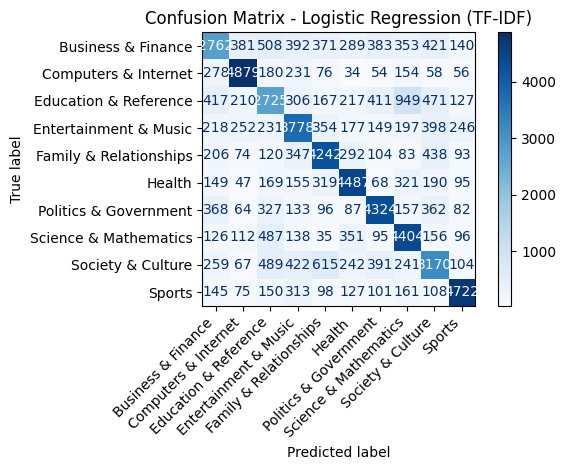


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2762,381,508,392,371,289,383,353,421,140
Computers & Internet,278,4879,180,231,76,34,54,154,58,56
Education & Reference,417,210,2725,306,167,217,411,949,471,127
Entertainment & Music,218,252,231,3778,354,177,149,197,398,246
Family & Relationships,206,74,120,347,4242,292,104,83,438,93
Health,149,47,169,155,319,4487,68,321,190,95
Politics & Government,368,64,327,133,96,87,4324,157,362,82
Science & Mathematics,126,112,487,138,35,351,95,4404,156,96
Society & Culture,259,67,489,422,615,242,391,241,3170,104


Training time: 4.12 seconds


In [ ]:
#Logistic Regression
print("\nTraining Logistic Regression")
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42
)

start_time = time. time()
lr_model.fit(X_train_tfidf, y_train_split)
lr_train_time = time. time() - start_time

# Validate
lr_val_pred = lr_model. predict(X_val_tfidf)
print(f"Validation Accuracy: {accuracy_score(y_val, lr_val_pred):.4f}")

# Test
lr_test_pred = lr_model.predict(X_test_tfidf)
evaluate_model(y_test, lr_test_pred, 'Logistic Regression (TF-IDF)', results)
plot_confusion_matrix(y_test, lr_test_pred, 'Logistic Regression (TF-IDF)', label_encoder.classes_)

print(f"Training time: {lr_train_time:.2f} seconds")

# #Random Forest
# print("\nTraining Random Forest")
# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=20,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     random_state=42,
#     n_jobs=-1
# )

# start_time = time. time()
# rf_model.fit(X_train_tfidf, y_train_split)
# rf_train_time = time. time() - start_time

# # Validate
# rf_val_pred = rf_model. predict(X_val_tfidf)
# print(f"Validation Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}")

# # Test
# rf_test_pred = rf_model.predict(X_test_tfidf)
# evaluate_model(y_test, rf_test_pred, 'Random Forest (TF-IDF)', results)
# plot_confusion_matrix(y_test, rf_test_pred, 'Random Forest (TF-IDF)', label_encoder. classes_)
# print(f"Training time: {rf_train_time:.2f} seconds")

# #Naive Bayes
# print("\nTraining Naive Bayes")
# nb_model = MultinomialNB(
#     alpha=1.0  # Laplace smoothing
# )

# start_time = time. time()
# nb_model.fit(X_train_tfidf, y_train_split)
# nb_train_time = time.time() - start_time

# # Validate
# nb_val_pred = nb_model.predict(X_val_tfidf)
# print(f"Validation Accuracy: {accuracy_score(y_val, nb_val_pred):.4f}")

# # Test
# nb_test_pred = nb_model.predict(X_test_tfidf)
# evaluate_model(y_test, nb_test_pred, 'Naive Bayes (TF-IDF)', results)
# plot_confusion_matrix(y_test, nb_test_pred, 'Naive Bayes (TF-IDF)', label_encoder.classes_)
# print(f"Training time: {nb_train_time:.2f} seconds")

Deep Neural Network with TF-IDF

In [ ]:
# Convert sparse to dense for DNN
X_train_tfidf_dense = X_train_tfidf.toarray()
X_val_tfidf_dense = X_val_tfidf. toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

# Build DNN model
dnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_tfidf_dense.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

dnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(dnn_model.summary())

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train DNN
print("\nTraining DNN")
start_time = time.time()
dnn_history = dnn_model.fit(
    X_train_tfidf_dense, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_tfidf_dense, y_val_cat),
    callbacks=[early_stop],
    verbose=1
)
dnn_train_time = time.time() - start_time


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,058 (9.93 MB)

 Trainable params: 2,602,058 (9.93 MB)

 Non-trainable params: 0 (0.00 B)

None

Training DNN
Epoch 1/50
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.5943 - loss: 1.2819 - val_accuracy: 0.6806 - val_loss: 1.0262
Epoch 2/50
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.7148 - loss: 0.9257 - val_accuracy: 0.6702 - val_loss: 1.0589
Epoch 3/50
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7654 - loss: 0.7576 - val_accuracy: 0.6632 - val_loss: 1.1478
Epoch 4/50
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8110 - loss: 0.6092 - val_accuracy: 0.6561 - val_loss: 1.2393
Epoch 5/50
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8514 - loss: 0.4774 - val_accuracy: 0.6511 - val_loss: 1.3596
Epoch 6/50
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8812 - loss: 0.3805 - val_accuracy: 0.6483 - val_loss: 1.5002


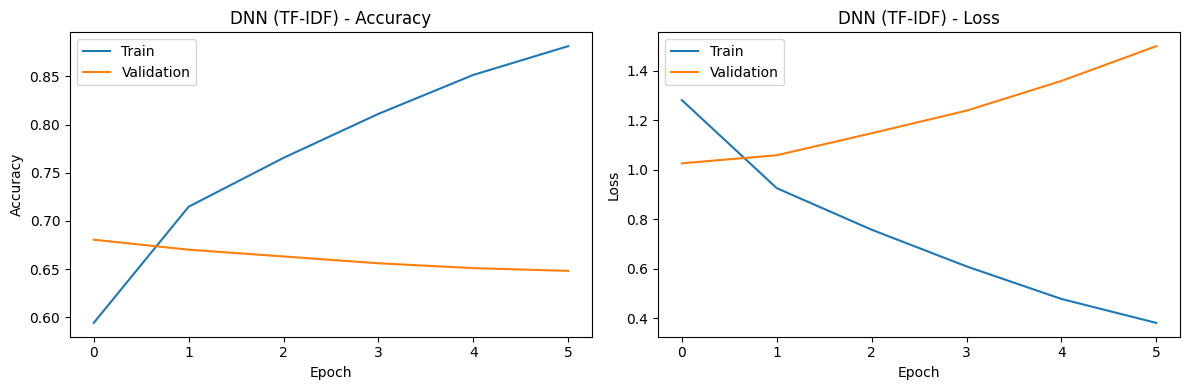

In [ ]:
# Plot training history
plt. figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(dnn_history.history['accuracy'], label='Train')
plt.plot(dnn_history. history['val_accuracy'], label='Validation')
plt.title('DNN (TF-IDF) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(dnn_history.history['loss'], label='Train')
plt.plot(dnn_history. history['val_loss'], label='Validation')
plt.title('DNN (TF-IDF) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Model: DNN (TF-IDF)


,Metric,Score
0,Accuracy,0.6554
1,F1-Score (Macro),0.6490



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6927,0.3795,0.4904,6000.0000
Computers & Internet,0.7841,0.8267,0.8048,6000.0000
Education & Reference,0.5470,0.3988,0.4613,6000.0000
Entertainment & Music,0.5281,0.6710,0.5910,6000.0000
Family & Relationships,0.6814,0.6984,0.6898,5999.0000
Health,0.6917,0.7640,0.7261,6000.0000
Politics & Government,0.6667,0.7512,0.7064,6000.0000
Science & Mathematics,0.6575,0.7113,0.6834,6000.0000
Society & Culture,0.5267,0.5575,0.5417,6000.0000
Sports,0.7943,0.7955,0.7949,6000.0000


<Figure size 800x600 with 0 Axes>

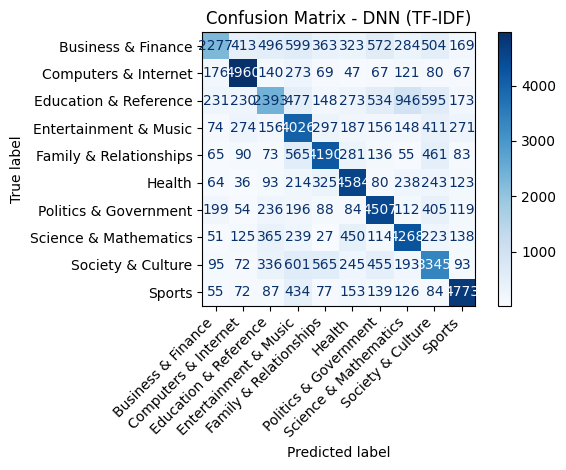


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2277,413,496,599,363,323,572,284,504,169
Computers & Internet,176,4960,140,273,69,47,67,121,80,67
Education & Reference,231,230,2393,477,148,273,534,946,595,173
Entertainment & Music,74,274,156,4026,297,187,156,148,411,271
Family & Relationships,65,90,73,565,4190,281,136,55,461,83
Health,64,36,93,214,325,4584,80,238,243,123
Politics & Government,199,54,236,196,88,84,4507,112,405,119
Science & Mathematics,51,125,365,239,27,450,114,4268,223,138
Society & Culture,95,72,336,601,565,245,455,193,3345,93


Training time: 105.73 seconds


In [ ]:
# Evaluate DNN
dnn_pred = np.argmax(dnn_model.predict(X_test_tfidf_dense), axis=1)
evaluate_model(y_test, dnn_pred, 'DNN (TF-IDF)', results)
plot_confusion_matrix(y_test, dnn_pred, 'DNN (TF-IDF)', label_encoder.classes_)
print(f"Training time: {dnn_train_time:.2f} seconds")

Neural Network Models with Skip-gram

In [ ]:
#Creating Embedding Layer
def create_embedding_layer():
    """Create embedding layer with pre-trained Skip-gram weights"""
    return Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    )


Training SimpleRNN


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

...

None
Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1203 - loss: 2.2925 - val_accuracy: 0.1122 - val_loss: 2.2994
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.1301 - loss: 2.2738 - val_accuracy: 0.1356 - val_loss: 2.2579
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.1502 - loss: 2.2283 - val_accuracy: 0.1385 - val_loss: 2.2399
Epoch 4/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.1417 - loss: 2.2484 - val_accuracy: 0.1751 - val_loss: 2.1854
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.1437 - loss: 2.2373 - val_accuracy: 0.1405 - val_loss: 2.2410
Epoch 6/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.1386 - loss: 2.2390 - val_accuracy: 0.1277 - val_loss: 2.2669
Epoch 7/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.1435 - loss: 2.2224 - val_accuracy: 0.1388 - val_loss: 2.2516
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
Model: SimpleRNN (Skip-gram)

,Metric,Score
0,Accuracy,0.1782
1,F1-Score (Macro),0.1106



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.5143,0.0030,0.0060,6000.0000
Computers & Internet,0.3609,0.0487,0.0858,6000.0000
Education & Reference,0.1365,0.0097,0.0181,6000.0000
Entertainment & Music,0.1556,0.0012,0.0023,6000.0000
Family & Relationships,0.4541,0.0148,0.0287,5999.0000
Health,0.4992,0.6862,0.5779,6000.0000
Politics & Government,0.2607,0.0213,0.0394,6000.0000
Science & Mathematics,0.4440,0.0410,0.0751,6000.0000
Society & Culture,0.2956,0.0400,0.0705,6000.0000
Sports,0.1136,0.9160,0.2021,6000.0000


<Figure size 800x600 with 0 Axes>

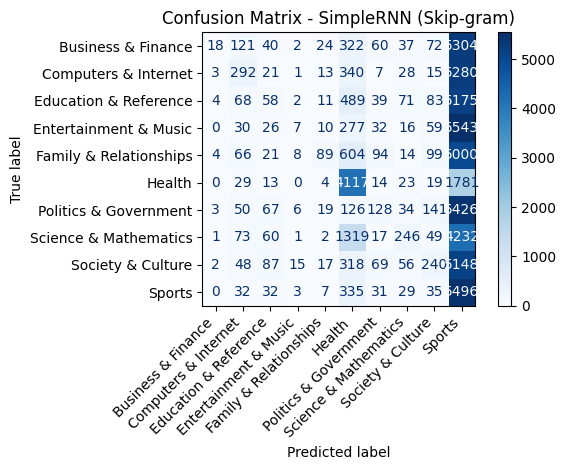


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,18,121,40,2,24,322,60,37,72,5304
Computers & Internet,3,292,21,1,13,340,7,28,15,5280
Education & Reference,4,68,58,2,11,489,39,71,83,5175
Entertainment & Music,0,30,26,7,10,277,32,16,59,5543
Family & Relationships,4,66,21,8,89,604,94,14,99,5000
Health,0,29,13,0,4,4117,14,23,19,1781
Politics & Government,3,50,67,6,19,126,128,34,141,5426
Science & Mathematics,1,73,60,1,2,1319,17,246,49,4232
Society & Culture,2,48,87,15,17,318,69,56,240,5148


Training time: 106.72 seconds


In [ ]:
# Simple RNN
print("\nTraining SimpleRNN")
rnn_model = Sequential([
    create_embedding_layer(),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(rnn_model.summary())

start_time = time. time()
rnn_history = rnn_model.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
rnn_train_time = time.time() - start_time

rnn_pred = np.argmax(rnn_model.predict(X_test_pad), axis=1)
evaluate_model(y_test, rnn_pred, 'SimpleRNN (Skip-gram)', results)
plot_confusion_matrix(y_test, rnn_pred, 'SimpleRNN (Skip-gram)', label_encoder.classes_)
print(f"Training time: {rnn_train_time:.2f} seconds")


Training GRU


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

...

None
Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3948 - loss: 1.7140 - val_accuracy: 0.6680 - val_loss: 1.0670
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - accuracy: 0.6810 - loss: 1.0399 - val_accuracy: 0.6943 - val_loss: 0.9827
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.7143 - loss: 0.9342 - val_accuracy: 0.6993 - val_loss: 0.9806
Epoch 4/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.7345 - loss: 0.8645 - val_accuracy: 0.6949 - val_loss: 1.0060
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.7554 - loss: 0.8053 - val_accuracy: 0.6873 - val_loss: 1.0476
Epoch 6/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.7743 - loss: 0.7447 - val_accuracy: 0.6820 - val_loss: 1.1014
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
Model: GRU (Skip-gram)


,Metric,Score
0,Accuracy,0.6642
1,F1-Score (Macro),0.6619



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6320,0.4277,0.5101,6000.0000
Computers & Internet,0.8357,0.8087,0.8220,6000.0000
Education & Reference,0.5402,0.4342,0.4814,6000.0000
Entertainment & Music,0.5218,0.7118,0.6022,6000.0000
Family & Relationships,0.7500,0.6391,0.6901,5999.0000
Health,0.7611,0.7418,0.7514,6000.0000
Politics & Government,0.6340,0.8058,0.7097,6000.0000
Science & Mathematics,0.6922,0.6977,0.6949,6000.0000
Society & Culture,0.5173,0.5790,0.5464,6000.0000
Sports,0.8268,0.7962,0.8112,6000.0000


<Figure size 800x600 with 0 Axes>

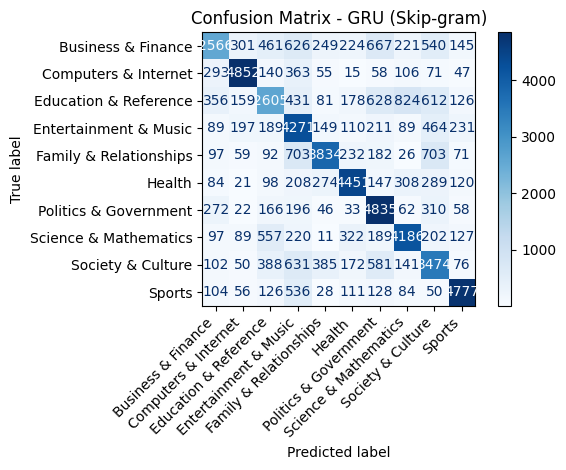


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2566,301,461,626,249,224,667,221,540,145
Computers & Internet,293,4852,140,363,55,15,58,106,71,47
Education & Reference,356,159,2605,431,81,178,628,824,612,126
Entertainment & Music,89,197,189,4271,149,110,211,89,464,231
Family & Relationships,97,59,92,703,3834,232,182,26,703,71
Health,84,21,98,208,274,4451,147,308,289,120
Politics & Government,272,22,166,196,46,33,4835,62,310,58
Science & Mathematics,97,89,557,220,11,322,189,4186,202,127
Society & Culture,102,50,388,631,385,172,581,141,3474,76


Training time: 205.71 seconds


In [ ]:
# GRU
print("\nTraining GRU")
gru_model = Sequential([
    create_embedding_layer(),
    GRU(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(gru_model.summary())

start_time = time.time()
gru_history = gru_model.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
gru_train_time = time. time() - start_time

gru_pred = np.argmax(gru_model.predict(X_test_pad), axis=1)
evaluate_model(y_test, gru_pred, 'GRU (Skip-gram)', results)
plot_confusion_matrix(y_test, gru_pred, 'GRU (Skip-gram)', label_encoder.classes_)
print(f"Training time: {gru_train_time:.2f} seconds")


Training LSTM


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

...

None
Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.1450 - loss: 2.2307 - val_accuracy: 0.1713 - val_loss: 2.1410
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.1753 - loss: 2.1679 - val_accuracy: 0.2383 - val_loss: 2.0371
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.3947 - loss: 1.6867 - val_accuracy: 0.6075 - val_loss: 1.2607
Epoch 4/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.6362 - loss: 1.1926 - val_accuracy: 0.6670 - val_loss: 1.0923
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.6881 - loss: 1.0423 - val_accuracy: 0.6770 - val_loss: 1.0512
Epoch 6/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.7166 - loss: 0.9569 - val_accuracy: 0.6800 - val_loss: 1.0541
Epoch 7/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.7350 - loss: 0.9022 - val_accuracy: 0.6747 - val_loss: 1.0802
Epoch 8/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.7

,Metric,Score
0,Accuracy,0.6278
1,F1-Score (Macro),0.6244



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6807,0.3677,0.4774,6000.0000
Computers & Internet,0.7963,0.8267,0.8112,6000.0000
Education & Reference,0.4159,0.5053,0.4563,6000.0000
Entertainment & Music,0.4809,0.5770,0.5246,6000.0000
Family & Relationships,0.7751,0.5376,0.6348,5999.0000
Health,0.7757,0.6860,0.7281,6000.0000
Politics & Government,0.7206,0.7247,0.7226,6000.0000
Science & Mathematics,0.5756,0.7345,0.6454,6000.0000
Society & Culture,0.6302,0.4647,0.5349,6000.0000
Sports,0.6057,0.8538,0.7087,6000.0000


<Figure size 800x600 with 0 Axes>

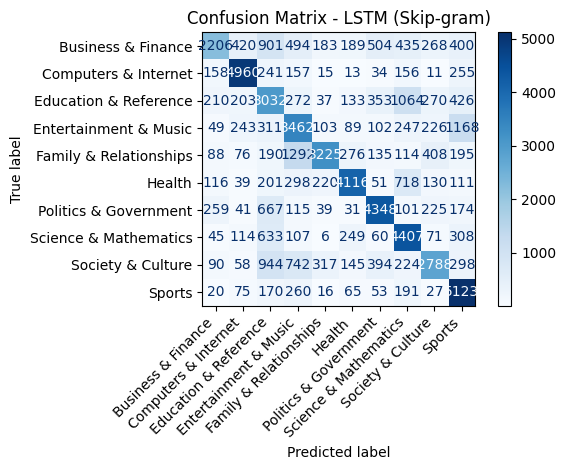


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2206,420,901,494,183,189,504,435,268,400
Computers & Internet,158,4960,241,157,15,13,34,156,11,255
Education & Reference,210,203,3032,272,37,133,353,1064,270,426
Entertainment & Music,49,243,311,3462,103,89,102,247,226,1168
Family & Relationships,88,76,190,1292,3225,276,135,114,408,195
Health,116,39,201,298,220,4116,51,718,130,111
Politics & Government,259,41,667,115,39,31,4348,101,225,174
Science & Mathematics,45,114,633,107,6,249,60,4407,71,308
Society & Culture,90,58,944,742,317,145,394,224,2788,298


Training time: 261.89 seconds


In [ ]:
# LSTM
print("\nTraining LSTM")
lstm_model = Sequential([
    create_embedding_layer(),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model. compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(lstm_model. summary())

start_time = time.time()
lstm_history = lstm_model. fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
lstm_train_time = time.time() - start_time

lstm_pred = np.argmax(lstm_model.predict(X_test_pad), axis=1)
evaluate_model(y_test, lstm_pred, 'LSTM (Skip-gram)', results)
plot_confusion_matrix(y_test, lstm_pred, 'LSTM (Skip-gram)', label_encoder.classes_)
print(f"Training time: {lstm_train_time:.2f} seconds")


Training Bidirectional SimpleRNN


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

...

None
Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.5173 - loss: 1.4732 - val_accuracy: 0.6312 - val_loss: 1.1664
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.6587 - loss: 1.1224 - val_accuracy: 0.6613 - val_loss: 1.1164
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.6905 - loss: 1.0299 - val_accuracy: 0.6594 - val_loss: 1.1247
Epoch 4/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7045 - loss: 1.0043 - val_accuracy: 0.6553 - val_loss: 1.1792
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7200 - loss: 0.9621 - val_accuracy: 0.6597 - val_loss: 1.1701
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
Model: Bidirectional SimpleRNN (Skip-gram)


,Metric,Score
0,Accuracy,0.6131
1,F1-Score (Macro),0.5972



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.7729,0.2422,0.3688,6000.0000
Computers & Internet,0.6750,0.8685,0.7596,6000.0000
Education & Reference,0.5860,0.2652,0.3651,6000.0000
Entertainment & Music,0.4713,0.6840,0.5581,6000.0000
Family & Relationships,0.5105,0.7003,0.5905,5999.0000
Health,0.6767,0.7497,0.7113,6000.0000
Politics & Government,0.6636,0.6715,0.6676,6000.0000
Science & Mathematics,0.6332,0.6758,0.6538,6000.0000
Society & Culture,0.5202,0.5143,0.5173,6000.0000
Sports,0.8006,0.7597,0.7796,6000.0000


<Figure size 800x600 with 0 Axes>

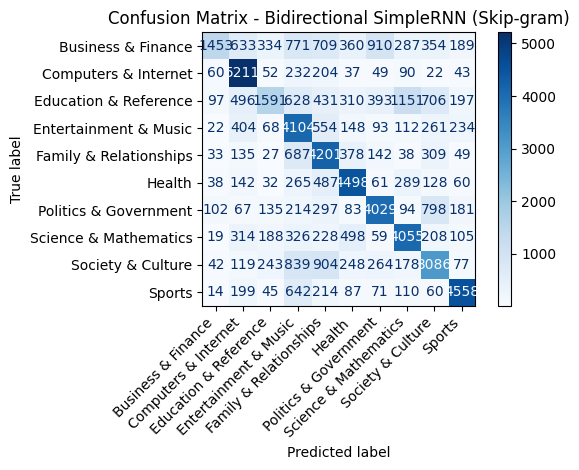


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,1453,633,334,771,709,360,910,287,354,189
Computers & Internet,60,5211,52,232,204,37,49,90,22,43
Education & Reference,97,496,1591,628,431,310,393,1151,706,197
Entertainment & Music,22,404,68,4104,554,148,93,112,261,234
Family & Relationships,33,135,27,687,4201,378,142,38,309,49
Health,38,142,32,265,487,4498,61,289,128,60
Politics & Government,102,67,135,214,297,83,4029,94,798,181
Science & Mathematics,19,314,188,326,228,498,59,4055,208,105
Society & Culture,42,119,243,839,904,248,264,178,3086,77


Training time:  97.48 seconds


In [ ]:
# Bidirectional SimpleRNN
print("\nTraining Bidirectional SimpleRNN")
bi_rnn_model = Sequential([
    create_embedding_layer(),
    Bidirectional(SimpleRNN(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

bi_rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(bi_rnn_model.summary())

start_time = time. time()
bi_rnn_history = bi_rnn_model.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
bi_rnn_train_time = time.time() - start_time

bi_rnn_pred = np.argmax(bi_rnn_model.predict(X_test_pad), axis=1)
evaluate_model(y_test, bi_rnn_pred, 'Bidirectional SimpleRNN (Skip-gram)', results)
plot_confusion_matrix(y_test, bi_rnn_pred, 'Bidirectional SimpleRNN (Skip-gram)', label_encoder.classes_)
print(f"Training time:  {bi_rnn_train_time:.2f} seconds")


Training Bidirectional GRU


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

...

None
Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.6004 - loss: 1.2346 - val_accuracy: 0.6948 - val_loss: 0.9742
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - accuracy: 0.7037 - loss: 0.9546 - val_accuracy: 0.7036 - val_loss: 0.9466
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.7271 - loss: 0.8764 - val_accuracy: 0.6981 - val_loss: 0.9672
Epoch 4/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 54s 46ms/step - accuracy: 0.7478 - loss: 0.8123 - val_accuracy: 0.6942 - val_loss: 1.0034
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.7663 - loss: 0.7533 - val_accuracy: 0.6828 - val_loss: 1.0584
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step
Model: Bidirectional GRU (Skip-gram)


,Metric,Score
0,Accuracy,0.6630
1,F1-Score (Macro),0.6615



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6774,0.4045,0.5065,6000.000
Computers & Internet,0.8009,0.8437,0.8218,6000.000
Education & Reference,0.5939,0.3815,0.4646,6000.000
Entertainment & Music,0.5795,0.6698,0.6214,6000.000
Family & Relationships,0.7206,0.6826,0.7011,5999.000
Health,0.7717,0.7368,0.7539,6000.000
Politics & Government,0.6305,0.7967,0.7039,6000.000
Science & Mathematics,0.7212,0.6705,0.6949,6000.000
Society & Culture,0.4239,0.6762,0.5211,6000.000
Sports,0.8922,0.7680,0.8254,6000.000


<Figure size 800x600 with 0 Axes>

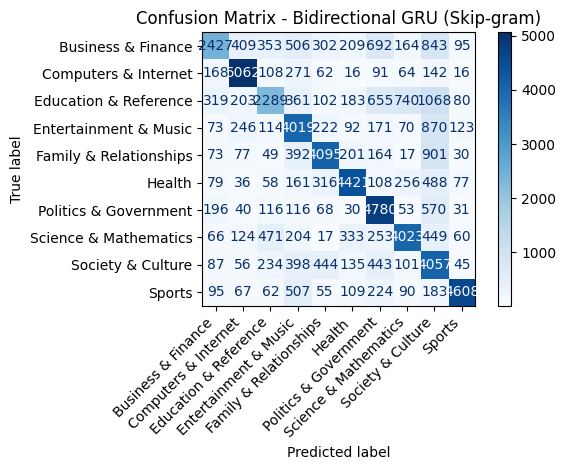


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2427,409,353,506,302,209,692,164,843,95
Computers & Internet,168,5062,108,271,62,16,91,64,142,16
Education & Reference,319,203,2289,361,102,183,655,740,1068,80
Entertainment & Music,73,246,114,4019,222,92,171,70,870,123
Family & Relationships,73,77,49,392,4095,201,164,17,901,30
Health,79,36,58,161,316,4421,108,256,488,77
Politics & Government,196,40,116,116,68,30,4780,53,570,31
Science & Mathematics,66,124,471,204,17,333,253,4023,449,60
Society & Culture,87,56,234,398,444,135,443,101,4057,45


Training time:  229.21 seconds


In [ ]:
# Bidirectional GRU
print("\nTraining Bidirectional GRU")
bi_gru_model = Sequential([
    create_embedding_layer(),
    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

bi_gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(bi_gru_model.summary())

start_time = time. time()
bi_gru_history = bi_gru_model.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
bi_gru_train_time = time.time() - start_time

bi_gru_pred = np.argmax(bi_gru_model.predict(X_test_pad), axis=1)
evaluate_model(y_test, bi_gru_pred, 'Bidirectional GRU (Skip-gram)', results)
plot_confusion_matrix(y_test, bi_gru_pred, 'Bidirectional GRU (Skip-gram)', label_encoder.classes_)
print(f"Training time:  {bi_gru_train_time:.2f} seconds")


Training Bidirectional LSTM


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

...

None
Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.6155 - loss: 1.2122 - val_accuracy: 0.6862 - val_loss: 1.0007
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.7030 - loss: 0.9668 - val_accuracy: 0.6982 - val_loss: 0.9625
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 58s 49ms/step - accuracy: 0.7286 - loss: 0.8853 - val_accuracy: 0.6997 - val_loss: 0.9778
Epoch 4/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.7488 - loss: 0.8214 - val_accuracy: 0.6976 - val_loss: 1.0058
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 56s 48ms/step - accuracy: 0.7652 - loss: 0.7678 - val_accuracy: 0.6918 - val_loss: 1.0308
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step
Model: Bidirectional LSTM (Skip-gram)


,Metric,Score
0,Accuracy,0.6579
1,F1-Score (Macro),0.6517



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6682,0.3807,0.4850,6000.0000
Computers & Internet,0.7882,0.8502,0.8180,6000.0000
Education & Reference,0.6307,0.3350,0.4376,6000.0000
Entertainment & Music,0.5928,0.6562,0.6229,6000.0000
Family & Relationships,0.7283,0.6599,0.6924,5999.0000
Health,0.7156,0.7788,0.7459,6000.0000
Politics & Government,0.5738,0.8295,0.6784,6000.0000
Science & Mathematics,0.6687,0.7317,0.6988,6000.0000
Society & Culture,0.4567,0.6338,0.5308,6000.0000
Sports,0.9135,0.7230,0.8071,6000.0000


<Figure size 800x600 with 0 Axes>

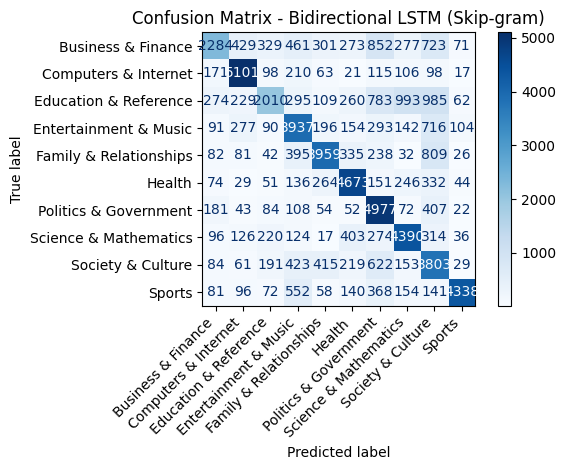


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2284,429,329,461,301,273,852,277,723,71
Computers & Internet,171,5101,98,210,63,21,115,106,98,17
Education & Reference,274,229,2010,295,109,260,783,993,985,62
Entertainment & Music,91,277,90,3937,196,154,293,142,716,104
Family & Relationships,82,81,42,395,3959,335,238,32,809,26
Health,74,29,51,136,264,4673,151,246,332,44
Politics & Government,181,43,84,108,54,52,4977,72,407,22
Science & Mathematics,96,126,220,124,17,403,274,4390,314,36
Society & Culture,84,61,191,423,415,219,622,153,3803,29


Training time:  238.78 seconds


In [ ]:
# Bidirectional LSTM
print("\nTraining Bidirectional LSTM")
bi_lstm_model = Sequential([
    create_embedding_layer(),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

bi_lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(bi_lstm_model. summary())

start_time = time.time()
bi_lstm_history = bi_lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
bi_lstm_train_time = time.time() - start_time

bi_lstm_pred = np.argmax(bi_lstm_model.predict(X_test_pad), axis=1)
evaluate_model(y_test, bi_lstm_pred, 'Bidirectional LSTM (Skip-gram)', results)
plot_confusion_matrix(y_test, bi_lstm_pred, 'Bidirectional LSTM (Skip-gram)', label_encoder.classes_)
print(f"Training time:  {bi_lstm_train_time:.2f} seconds")


Training DNN with Skip-gram


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

...

None
Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5216 - loss: 1.4687 - val_accuracy: 0.6531 - val_loss: 1.1084
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6413 - loss: 1.1524 - val_accuracy: 0.6741 - val_loss: 1.0483
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6694 - loss: 1.0662 - val_accuracy: 0.6785 - val_loss: 1.0320
Epoch 4/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6852 - loss: 1.0132 - val_accuracy: 0.6771 - val_loss: 1.0388
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6988 - loss: 0.9707 - val_accuracy: 0.6817 - val_loss: 1.0275
Epoch 6/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7097 - loss: 0.9334 - val_accuracy: 0.6798 - val_loss: 1.0355
Epoch 7/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7173 - loss: 0.9055 - val_accuracy: 0.6780 - val_loss: 1.0437
Epoch 8/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7240 - loss: 0.88

,Metric,Score
0,Accuracy,0.6579
1,F1-Score (Macro),0.6568



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.5975,0.4268,0.4980,6000.0000
Computers & Internet,0.8023,0.8358,0.8187,6000.0000
Education & Reference,0.4514,0.4863,0.4682,6000.0000
Entertainment & Music,0.5595,0.6763,0.6124,6000.0000
Family & Relationships,0.7269,0.6439,0.6829,5999.0000
Health,0.7738,0.7145,0.7430,6000.0000
Politics & Government,0.6457,0.7820,0.7073,6000.0000
Science & Mathematics,0.6901,0.6730,0.6815,6000.0000
Society & Culture,0.5422,0.5418,0.5420,6000.0000
Sports,0.8296,0.7987,0.8139,6000.0000


<Figure size 800x600 with 0 Axes>

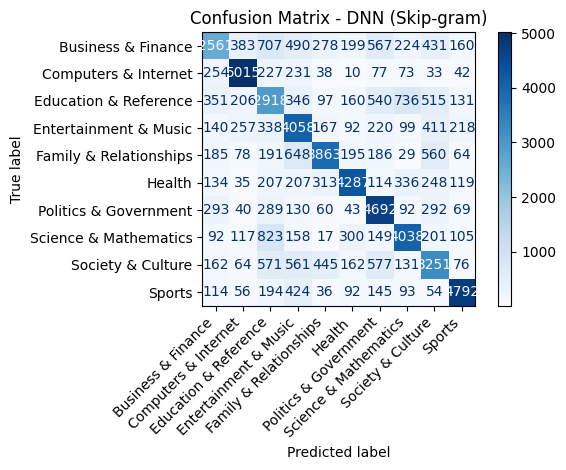


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2561,383,707,490,278,199,567,224,431,160
Computers & Internet,254,5015,227,231,38,10,77,73,33,42
Education & Reference,351,206,2918,346,97,160,540,736,515,131
Entertainment & Music,140,257,338,4058,167,92,220,99,411,218
Family & Relationships,185,78,191,648,3863,195,186,29,560,64
Health,134,35,207,207,313,4287,114,336,248,119
Politics & Government,293,40,289,130,60,43,4692,92,292,69
Science & Mathematics,92,117,823,158,17,300,149,4038,201,105
Society & Culture,162,64,571,561,445,162,577,131,3251,76


Training time: 41.77 seconds


In [ ]:
# Deep Neural Network with Skip-gram (Dense layers after pooling)
print("\nTraining DNN with Skip-gram")
dnn_skipgram_model = Sequential([
    create_embedding_layer(),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

dnn_skipgram_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(dnn_skipgram_model.summary())

start_time = time. time()
dnn_skipgram_history = dnn_skipgram_model.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
dnn_skipgram_train_time = time.time() - start_time

dnn_skipgram_pred = np.argmax(dnn_skipgram_model.predict(X_test_pad), axis=1)
evaluate_model(y_test, dnn_skipgram_pred, 'DNN (Skip-gram)', results)
plot_confusion_matrix(y_test, dnn_skipgram_pred, 'DNN (Skip-gram)', label_encoder.classes_)
print(f"Training time: {dnn_skipgram_train_time:.2f} seconds")

Hyper Parameter Tuning


[1] TUNING LOGISTIC REGRESSION
Baseline Performance:  Acc=0.6582, F1=0.6554
Baseline Hyperparameters: C=1. 0, solver='lbfgs'

Tuning C and solver...

Best Hyperparameters:  C=0.5, solver='lbfgs'
Validation F1: 0.6782
Model: Logistic Regression (Tuned)


,Metric,Score
0,Accuracy,0.6584
1,F1-Score (Macro),0.6551



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.5783,0.4610,0.5130,6000.0000
Computers & Internet,0.7842,0.8117,0.7977,6000.0000
Education & Reference,0.5160,0.4515,0.4816,6000.0000
Entertainment & Music,0.6056,0.6300,0.6175,6000.0000
Family & Relationships,0.6639,0.7118,0.6870,5999.0000
Health,0.7063,0.7493,0.7272,6000.0000
Politics & Government,0.7095,0.7232,0.7162,6000.0000
Science & Mathematics,0.6188,0.7413,0.6746,6000.0000
Society & Culture,0.5558,0.5260,0.5405,6000.0000
Sports,0.8143,0.7782,0.7958,6000.0000


<Figure size 800x600 with 0 Axes>

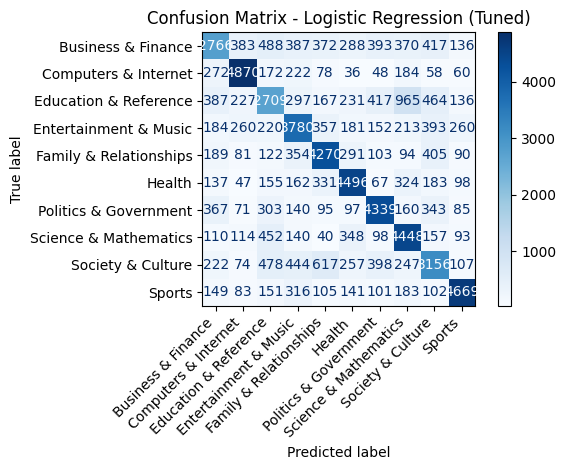


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2766,383,488,387,372,288,393,370,417,136
Computers & Internet,272,4870,172,222,78,36,48,184,58,60
Education & Reference,387,227,2709,297,167,231,417,965,464,136
Entertainment & Music,184,260,220,3780,357,181,152,213,393,260
Family & Relationships,189,81,122,354,4270,291,103,94,405,90
Health,137,47,155,162,331,4496,67,324,183,98
Politics & Government,367,71,303,140,95,97,4339,160,343,85
Science & Mathematics,110,114,452,140,40,348,98,4448,157,93
Society & Culture,222,74,478,444,617,257,398,247,3156,107



Logistic Regression Tuning Results (All Combinations):


,C,solver,val_accuracy,val_f1
2,0.5,lbfgs,0.6803,0.6782
3,0.5,saga,0.6798,0.6776
4,1.0,lbfgs,0.6785,0.6766
5,1.0,saga,0.6784,0.6765
7,2.0,saga,0.6701,0.6686
6,2.0,lbfgs,0.6692,0.6676
8,5.0,lbfgs,0.6569,0.6558
9,5.0,saga,0.6563,0.6553
0,0.1,lbfgs,0.6586,0.6552
1,0.1,saga,0.6585,0.6552


In [ ]:
# Store tuning results
tuning_results = {}

#1. Logistic Regression Tuning
print("\n[1] TUNING LOGISTIC REGRESSION")

# Current baseline already trained above
baseline_lr_acc = results['Logistic Regression (TF-IDF)']['accuracy']
baseline_lr_f1 = results['Logistic Regression (TF-IDF)']['f1_score']

print(f"Baseline Performance:  Acc={baseline_lr_acc:.4f}, F1={baseline_lr_f1:.4f}")
print(f"Baseline Hyperparameters: C=1. 0, solver='lbfgs'")

# Tune:  C and solver
print("\nTuning C and solver...")
best_lr_val_f1 = 0
best_lr_params = {}

lr_tuning_results = []

for C in [0.1, 0.5, 1.0, 2.0, 5.0]:
    for solver in ['lbfgs', 'saga']:
        lr_temp = LogisticRegression(
            C=C,
            solver=solver,
            max_iter=1000,
            multi_class='multinomial',
            random_state=42
        )
        lr_temp.fit(X_train_tfidf, y_train_split)
        val_pred = lr_temp. predict(X_val_tfidf)
        val_acc = accuracy_score(y_val, val_pred)
        val_f1 = f1_score(y_val, val_pred, average='macro')

        lr_tuning_results.append({
            'C': C,
            'solver':  solver,
            'val_accuracy': val_acc,
            'val_f1': val_f1
        })

        if val_f1 > best_lr_val_f1:
            best_lr_val_f1 = val_f1
            best_lr_params = {'C': C, 'solver': solver}
            best_lr_model = lr_temp

print(f"\nBest Hyperparameters:  C={best_lr_params['C']}, solver='{best_lr_params['solver']}'")
print(f"Validation F1: {best_lr_val_f1:.4f}")

# Test with best model
lr_tuned_pred = best_lr_model. predict(X_test_tfidf)
evaluate_model(y_test, lr_tuned_pred, 'Logistic Regression (Tuned)', results)
plot_confusion_matrix(y_test, lr_tuned_pred, 'Logistic Regression (Tuned)', label_encoder. classes_)

# Store comparison
tuning_results['Logistic Regression'] = {
    'baseline':  {'accuracy': baseline_lr_acc, 'f1':  baseline_lr_f1, 'params': {'C': 1.0, 'solver': 'lbfgs'}},
    'tuned': {'accuracy':  results['Logistic Regression (Tuned)']['accuracy'],
              'f1': results['Logistic Regression (Tuned)']['f1_score'],
              'params':  best_lr_params}
}

# Display tuning results table
print("\nLogistic Regression Tuning Results (All Combinations):")
lr_tune_df = pd. DataFrame(lr_tuning_results).sort_values('val_f1', ascending=False)
lr_tune_df = lr_tune_df.round(4)
display(lr_tune_df)


[2] TUNING DNN (TF-IDF)
Baseline Performance: Acc=0.6554, F1=0.6490
Baseline:  arch=[256,128,64], dropout=[0.5,0.3,0.2], batch=64

Tuning dropout and batch_size...
  Testing:  dropout=low, batch=32
    Val Acc: 0.6776, Val F1: 0.6712
  Testing:  dropout=low, batch=64
    Val Acc: 0.6794, Val F1: 0.6745
  Testing:  dropout=low, batch=128
    Val Acc: 0.6806, Val F1: 0.6761
  Testing:  dropout=baseline, batch=32
    Val Acc: 0.6791, Val F1: 0.6742
  Testing:  dropout=baseline, batch=64
    Val Acc: 0.6798, Val F1: 0.6744
  Testing:  dropout=baseline, batch=128
    Val Acc: 0.6815, Val F1: 0.6765
  Testing:  dropout=high, batch=32
    Val Acc: 0.6768, Val F1: 0.6718
  Testing:  dropout=high, batch=64
    Val Acc: 0.6788, Val F1: 0.6733
  Testing:  dropout=high, batch=128
    Val Acc: 0.6830, Val F1: 0.6776

Best Hyperparameters:
  Dropout: high [0.6, 0.4, 0.3]
  Batch Size:  128
  Validation F1: 0.6776
Model: DNN (TF-IDF) - Tuned


,Metric,Score
0,Accuracy,0.6556
1,F1-Score (Macro),0.6504



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6650,0.3882,0.4902,6000.0000
Computers & Internet,0.7741,0.8297,0.8009,6000.0000
Education & Reference,0.4998,0.4412,0.4687,6000.0000
Entertainment & Music,0.5376,0.6607,0.5928,6000.0000
Family & Relationships,0.6713,0.7101,0.6902,5999.0000
Health,0.7185,0.7457,0.7318,6000.0000
Politics & Government,0.6826,0.7493,0.7144,6000.0000
Science & Mathematics,0.6479,0.7137,0.6792,6000.0000
Society & Culture,0.5503,0.5223,0.5360,6000.0000
Sports,0.8043,0.7952,0.7997,6000.0000


<Figure size 800x600 with 0 Axes>

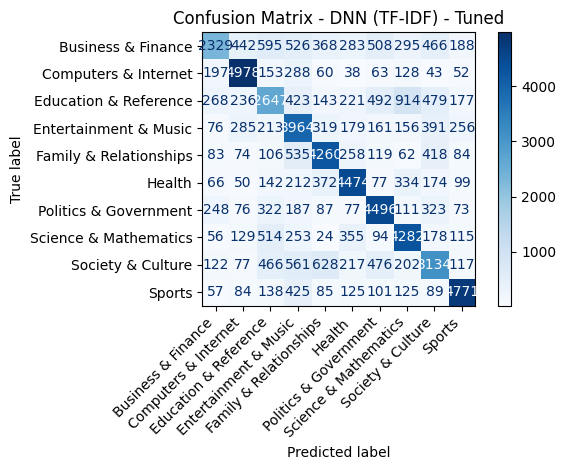


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2329,442,595,526,368,283,508,295,466,188
Computers & Internet,197,4978,153,288,60,38,63,128,43,52
Education & Reference,268,236,2647,423,143,221,492,914,479,177
Entertainment & Music,76,285,213,3964,319,179,161,156,391,256
Family & Relationships,83,74,106,535,4260,258,119,62,418,84
Health,66,50,142,212,372,4474,77,334,174,99
Politics & Government,248,76,322,187,87,77,4496,111,323,73
Science & Mathematics,56,129,514,253,24,355,94,4282,178,115
Society & Culture,122,77,466,561,628,217,476,202,3134,117



DNN Tuning Results:


,dropout,batch_size,val_accuracy,val_f1
8,high,128,0.6830,0.6776
5,baseline,128,0.6815,0.6765
2,low,128,0.6806,0.6761
1,low,64,0.6794,0.6745
4,baseline,64,0.6798,0.6744
3,baseline,32,0.6791,0.6742
7,high,64,0.6788,0.6733
6,high,32,0.6768,0.6718
0,low,32,0.6776,0.6712


In [ ]:
#DNN TF-IDF Tuning
print("\n[2] TUNING DNN (TF-IDF)")

baseline_dnn_acc = results['DNN (TF-IDF)']['accuracy']
baseline_dnn_f1 = results['DNN (TF-IDF)']['f1_score']

print(f"Baseline Performance: Acc={baseline_dnn_acc:.4f}, F1={baseline_dnn_f1:.4f}")
print(f"Baseline:  arch=[256,128,64], dropout=[0.5,0.3,0.2], batch=64")

# Tune: dropout and batch_size (keeping architecture same for simplicity)
print("\nTuning dropout and batch_size...")

dropout_configs = [
    ([0.4, 0.2, 0.1], "low"),
    ([0.5, 0.3, 0.2], "baseline"),
    ([0.6, 0.4, 0.3], "high")
]

batch_sizes = [32, 64, 128]

best_dnn_val_f1 = 0
best_dnn_params = {}
dnn_tuning_results = []

for dropout_list, drop_name in dropout_configs:
    for batch_size in batch_sizes:
        print(f"  Testing:  dropout={drop_name}, batch={batch_size}")

        model_temp = Sequential([
            Dense(256, activation='relu', input_shape=(X_train_tfidf_dense.shape[1],)),
            Dropout(dropout_list[0]),
            Dense(128, activation='relu'),
            Dropout(dropout_list[1]),
            Dense(64, activation='relu'),
            Dropout(dropout_list[2]),
            Dense(num_classes, activation='softmax')
        ])

        model_temp.compile(optimizer='adam', loss='categorical_crossentropy',
                          metrics=['accuracy'])

        history_temp = model_temp.fit(
            X_train_tfidf_dense, y_train_cat,
            epochs=50,
            batch_size=batch_size,
            validation_data=(X_val_tfidf_dense, y_val_cat),
            callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                    restore_best_weights=True)],
            verbose=0
        )

        val_pred_temp = np.argmax(model_temp.predict(X_val_tfidf_dense, verbose=0), axis=1)
        val_acc = accuracy_score(y_val, val_pred_temp)
        val_f1 = f1_score(y_val, val_pred_temp, average='macro')

        dnn_tuning_results.append({
            'dropout':  drop_name,
            'batch_size':  batch_size,
            'val_accuracy': val_acc,
            'val_f1': val_f1
        })

        print(f"    Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_dnn_val_f1:
            best_dnn_val_f1 = val_f1
            best_dnn_params = {
                'dropout':  dropout_list,
                'dropout_name': drop_name,
                'batch_size': batch_size
            }
            best_dnn_model = model_temp

print(f"\nBest Hyperparameters:")
print(f"  Dropout: {best_dnn_params['dropout_name']} {best_dnn_params['dropout']}")
print(f"  Batch Size:  {best_dnn_params['batch_size']}")
print(f"  Validation F1: {best_dnn_val_f1:.4f}")

dnn_tuned_pred = np.argmax(best_dnn_model.predict(X_test_tfidf_dense, verbose=0), axis=1)
evaluate_model(y_test, dnn_tuned_pred, 'DNN (TF-IDF) - Tuned', results)
plot_confusion_matrix(y_test, dnn_tuned_pred, 'DNN (TF-IDF) - Tuned', label_encoder. classes_)

tuning_results['DNN (TF-IDF)'] = {
    'baseline': {'accuracy': baseline_dnn_acc, 'f1': baseline_dnn_f1,
                 'params': {'dropout': [0.5,0.3,0.2], 'batch':  64}},
    'tuned':  {'accuracy': results['DNN (TF-IDF) - Tuned']['accuracy'],
              'f1': results['DNN (TF-IDF) - Tuned']['f1_score'],
              'params': best_dnn_params}
}

print("\nDNN Tuning Results:")
dnn_tune_df = pd. DataFrame(dnn_tuning_results).sort_values('val_f1', ascending=False)
dnn_tune_df = dnn_tune_df.round(4)
display(dnn_tune_df)


[3] TUNING SimpleRNN
Baseline Performance:  Acc=0.1782, F1=0.1106
Baseline:  units=64, dropout=0.5
  Testing: units=32, dropout=0.3
    Val Acc: 0.1461, Val F1: 0.1083
  Testing: units=32, dropout=0.5
    Val Acc: 0.1896, Val F1: 0.1156
  Testing: units=32, dropout=0.6
    Val Acc: 0.1462, Val F1: 0.1081
  Testing: units=64, dropout=0.3
    Val Acc: 0.1371, Val F1: 0.0922
  Testing: units=64, dropout=0.5
    Val Acc: 0.1030, Val F1: 0.0235
  Testing: units=64, dropout=0.6
    Val Acc: 0.1995, Val F1: 0.1271
  Testing: units=128, dropout=0.3
    Val Acc: 0.1280, Val F1: 0.0750
  Testing: units=128, dropout=0.5
    Val Acc: 0.1390, Val F1: 0.0946
  Testing: units=128, dropout=0.6
    Val Acc: 0.1088, Val F1: 0.0328

Best Hyperparameters:  units=64, dropout=0.6
Validation F1: 0.1271
Model: SimpleRNN (Tuned)


,Metric,Score
0,Accuracy,0.1983
1,F1-Score (Macro),0.1247



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.3735,0.0052,0.0102,6000.0000
Computers & Internet,0.3492,0.7585,0.4783,6000.0000
Education & Reference,0.1538,0.0003,0.0007,6000.0000
Entertainment & Music,0.1280,0.9045,0.2242,6000.0000
Family & Relationships,0.4417,0.0562,0.0997,5999.0000
Health,0.6117,0.0698,0.1254,6000.0000
Politics & Government,0.3978,0.0795,0.1325,6000.0000
Science & Mathematics,0.7653,0.0125,0.0246,6000.0000
Society & Culture,0.3401,0.0950,0.1485,6000.0000
Sports,0.2564,0.0017,0.0033,6000.0000


<Figure size 800x600 with 0 Axes>

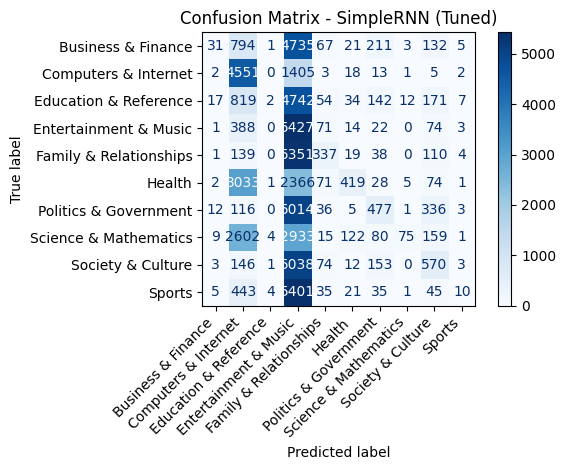


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,31,794,1,4735,67,21,211,3,132,5
Computers & Internet,2,4551,0,1405,3,18,13,1,5,2
Education & Reference,17,819,2,4742,54,34,142,12,171,7
Entertainment & Music,1,388,0,5427,71,14,22,0,74,3
Family & Relationships,1,139,0,5351,337,19,38,0,110,4
Health,2,3033,1,2366,71,419,28,5,74,1
Politics & Government,12,116,0,5014,36,5,477,1,336,3
Science & Mathematics,9,2602,4,2933,15,122,80,75,159,1
Society & Culture,3,146,1,5038,74,12,153,0,570,3



SimpleRNN Tuning Results:


,units,dropout,val_accuracy,val_f1
5,64,0.6,0.1995,0.1271
1,32,0.5,0.1896,0.1156
0,32,0.3,0.1461,0.1083
2,32,0.6,0.1462,0.1081
7,128,0.5,0.1390,0.0946
3,64,0.3,0.1371,0.0922
6,128,0.3,0.1280,0.0750
8,128,0.6,0.1088,0.0328
4,64,0.5,0.1030,0.0235


In [ ]:
#Simple RNN Tuning
print("\n[3] TUNING SimpleRNN")

baseline_rnn_acc = results['SimpleRNN (Skip-gram)']['accuracy']
baseline_rnn_f1 = results['SimpleRNN (Skip-gram)']['f1_score']

print(f"Baseline Performance:  Acc={baseline_rnn_acc:.4f}, F1={baseline_rnn_f1:.4f}")
print(f"Baseline:  units=64, dropout=0.5")

units_options = [32, 64, 128]
dropout_options = [0.3, 0.5, 0.6]

best_rnn_val_f1 = 0
best_rnn_params = {}
rnn_tuning_results = []

for units in units_options:
    for dropout in dropout_options:
        print(f"  Testing: units={units}, dropout={dropout}")

        model_temp = Sequential([
            create_embedding_layer(),
            SimpleRNN(units, return_sequences=False),
            Dropout(dropout),
            Dense(32, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])
        model_temp.compile(optimizer='adam', loss='categorical_crossentropy',
                          metrics=['accuracy'])

        history_temp = model_temp.fit(
            X_train_pad, y_train_cat,
            epochs=20,
            batch_size=64,
            validation_data=(X_val_pad, y_val_cat),
            callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                    restore_best_weights=True)],
            verbose=0
        )

        val_pred_temp = np. argmax(model_temp.predict(X_val_pad, verbose=0), axis=1)
        val_acc = accuracy_score(y_val, val_pred_temp)
        val_f1 = f1_score(y_val, val_pred_temp, average='macro')

        rnn_tuning_results.append({
            'units': units,
            'dropout': dropout,
            'val_accuracy':  val_acc,
            'val_f1': val_f1
        })

        print(f"    Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_rnn_val_f1:
            best_rnn_val_f1 = val_f1
            best_rnn_params = {'units': units, 'dropout': dropout}
            best_rnn_model = model_temp

print(f"\nBest Hyperparameters:  units={best_rnn_params['units']}, dropout={best_rnn_params['dropout']}")
print(f"Validation F1: {best_rnn_val_f1:.4f}")

rnn_tuned_pred = np.argmax(best_rnn_model.predict(X_test_pad, verbose=0), axis=1)
evaluate_model(y_test, rnn_tuned_pred, 'SimpleRNN (Tuned)', results)
plot_confusion_matrix(y_test, rnn_tuned_pred, 'SimpleRNN (Tuned)', label_encoder.classes_)

tuning_results['SimpleRNN'] = {
    'baseline': {'accuracy': baseline_rnn_acc, 'f1': baseline_rnn_f1,
                 'params': {'units': 64, 'dropout': 0.5}},
    'tuned':  {'accuracy': results['SimpleRNN (Tuned)']['accuracy'],
              'f1': results['SimpleRNN (Tuned)']['f1_score'],
              'params': best_rnn_params}
}

print("\nSimpleRNN Tuning Results:")
rnn_tune_df = pd. DataFrame(rnn_tuning_results).sort_values('val_f1', ascending=False)
display(rnn_tune_df. round(4))


[4] TUNING GRU
Baseline Performance: Acc=0.6642, F1=0.6619
Baseline: units=64, dropout=0.5
  Testing: units=32, dropout=0.3
    Val Acc:  0.6770, Val F1: 0.6761
  Testing: units=32, dropout=0.5
    Val Acc:  0.6909, Val F1: 0.6860
  Testing: units=32, dropout=0.6
    Val Acc:  0.6820, Val F1: 0.6787
  Testing: units=64, dropout=0.3
    Val Acc:  0.6941, Val F1: 0.6911
  Testing: units=64, dropout=0.5
    Val Acc:  0.6945, Val F1: 0.6895
  Testing: units=64, dropout=0.6
    Val Acc:  0.6935, Val F1: 0.6896
  Testing: units=128, dropout=0.3
    Val Acc:  0.7050, Val F1: 0.7003
  Testing: units=128, dropout=0.5
    Val Acc:  0.6997, Val F1: 0.6963
  Testing: units=128, dropout=0.6
    Val Acc:  0.7033, Val F1: 0.6996

Best Hyperparameters:  units=128, dropout=0.3
Validation F1: 0.7003
Model: GRU (Tuned)


,Metric,Score
0,Accuracy,0.6718
1,F1-Score (Macro),0.6655



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6445,0.4178,0.5070,6000.0000
Computers & Internet,0.7647,0.8678,0.8130,6000.0000
Education & Reference,0.5662,0.4128,0.4775,6000.0000
Entertainment & Music,0.6178,0.6463,0.6318,6000.0000
Family & Relationships,0.7565,0.6411,0.6940,5999.0000
Health,0.7067,0.7743,0.7390,6000.0000
Politics & Government,0.6784,0.7873,0.7288,6000.0000
Science & Mathematics,0.5964,0.7887,0.6792,6000.0000
Society & Culture,0.5380,0.5765,0.5566,6000.0000
Sports,0.8529,0.8052,0.8284,6000.0000


<Figure size 800x600 with 0 Axes>

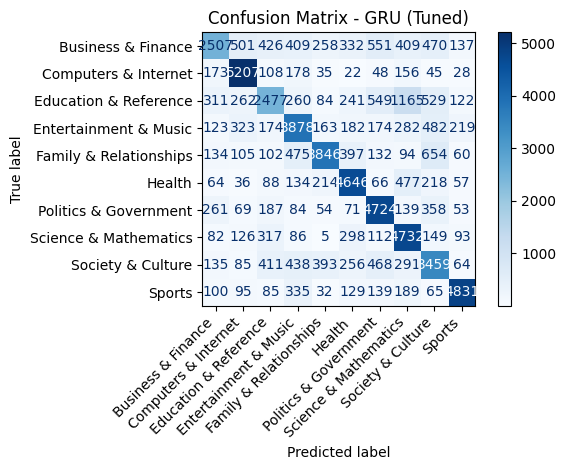


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2507,501,426,409,258,332,551,409,470,137
Computers & Internet,173,5207,108,178,35,22,48,156,45,28
Education & Reference,311,262,2477,260,84,241,549,1165,529,122
Entertainment & Music,123,323,174,3878,163,182,174,282,482,219
Family & Relationships,134,105,102,475,3846,397,132,94,654,60
Health,64,36,88,134,214,4646,66,477,218,57
Politics & Government,261,69,187,84,54,71,4724,139,358,53
Science & Mathematics,82,126,317,86,5,298,112,4732,149,93
Society & Culture,135,85,411,438,393,256,468,291,3459,64



GRU Tuning Results:


,units,dropout,val_accuracy,val_f1
6,128,0.3,0.7050,0.7003
8,128,0.6,0.7033,0.6996
7,128,0.5,0.6997,0.6963
3,64,0.3,0.6941,0.6911
5,64,0.6,0.6935,0.6896
4,64,0.5,0.6945,0.6895
1,32,0.5,0.6909,0.6860
2,32,0.6,0.6820,0.6787
0,32,0.3,0.6770,0.6761


In [ ]:
#GRU Tuning
print("\n[4] TUNING GRU")

baseline_gru_acc = results['GRU (Skip-gram)']['accuracy']
baseline_gru_f1 = results['GRU (Skip-gram)']['f1_score']

print(f"Baseline Performance: Acc={baseline_gru_acc:.4f}, F1={baseline_gru_f1:.4f}")
print(f"Baseline: units=64, dropout=0.5")

units_options = [32, 64, 128]
dropout_options = [0.3, 0.5, 0.6]

best_gru_val_f1 = 0
best_gru_params = {}
gru_tuning_results = []

for units in units_options:
    for dropout in dropout_options:
        print(f"  Testing: units={units}, dropout={dropout}")

        model_temp = Sequential([
            create_embedding_layer(),
            GRU(units, return_sequences=False),
            Dropout(dropout),
            Dense(32, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])
        model_temp.compile(optimizer='adam', loss='categorical_crossentropy',
                          metrics=['accuracy'])

        history_temp = model_temp.fit(
            X_train_pad, y_train_cat,
            epochs=20,
            batch_size=64,
            validation_data=(X_val_pad, y_val_cat),
            callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                    restore_best_weights=True)],
            verbose=0
        )

        val_pred_temp = np.argmax(model_temp. predict(X_val_pad, verbose=0), axis=1)
        val_acc = accuracy_score(y_val, val_pred_temp)
        val_f1 = f1_score(y_val, val_pred_temp, average='macro')

        gru_tuning_results. append({
            'units': units,
            'dropout': dropout,
            'val_accuracy': val_acc,
            'val_f1':  val_f1
        })

        print(f"    Val Acc:  {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_gru_val_f1:
            best_gru_val_f1 = val_f1
            best_gru_params = {'units': units, 'dropout': dropout}
            best_gru_model = model_temp

print(f"\nBest Hyperparameters:  units={best_gru_params['units']}, dropout={best_gru_params['dropout']}")
print(f"Validation F1: {best_gru_val_f1:.4f}")

gru_tuned_pred = np.argmax(best_gru_model.predict(X_test_pad, verbose=0), axis=1)
evaluate_model(y_test, gru_tuned_pred, 'GRU (Tuned)', results)
plot_confusion_matrix(y_test, gru_tuned_pred, 'GRU (Tuned)', label_encoder.classes_)

tuning_results['GRU'] = {
    'baseline': {'accuracy':  baseline_gru_acc, 'f1': baseline_gru_f1,
                 'params': {'units': 64, 'dropout': 0.5}},
    'tuned': {'accuracy': results['GRU (Tuned)']['accuracy'],
              'f1':  results['GRU (Tuned)']['f1_score'],
              'params': best_gru_params}
}

print("\nGRU Tuning Results:")
gru_tune_df = pd.DataFrame(gru_tuning_results).sort_values('val_f1', ascending=False)
display(gru_tune_df. round(4))



[5] TUNING LSTM
Baseline Performance:  Acc=0.6278, F1=0.6244
Baseline: units=64, dropout=0.5
  Testing: units=32, dropout=0.3
    Val Acc:  0.6678, Val F1: 0.6659
  Testing: units=32, dropout=0.5
    Val Acc:  0.6706, Val F1: 0.6674
  Testing: units=32, dropout=0.6
    Val Acc:  0.6709, Val F1: 0.6664
  Testing: units=64, dropout=0.3
    Val Acc:  0.6841, Val F1: 0.6820
  Testing: units=64, dropout=0.5
    Val Acc:  0.6858, Val F1: 0.6832
  Testing: units=64, dropout=0.6
    Val Acc:  0.6771, Val F1: 0.6756
  Testing: units=128, dropout=0.3
    Val Acc:  0.6871, Val F1: 0.6827
  Testing: units=128, dropout=0.5
    Val Acc:  0.6713, Val F1: 0.6720
  Testing: units=128, dropout=0.6
    Val Acc:  0.6743, Val F1: 0.6696

Best Hyperparameters: units=64, dropout=0.5
Validation F1: 0.6832
Model: LSTM (Tuned)


,Metric,Score
0,Accuracy,0.6498
1,F1-Score (Macro),0.6437



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.7157,0.3612,0.4801,6000.0000
Computers & Internet,0.7707,0.8402,0.8039,6000.0000
Education & Reference,0.4765,0.4192,0.4460,6000.0000
Entertainment & Music,0.5130,0.6710,0.5815,6000.0000
Family & Relationships,0.7412,0.6213,0.6760,5999.0000
Health,0.7096,0.7552,0.7317,6000.0000
Politics & Government,0.7313,0.7258,0.7286,6000.0000
Science & Mathematics,0.5905,0.7560,0.6631,6000.0000
Society & Culture,0.5641,0.5373,0.5504,6000.0000
Sports,0.7438,0.8107,0.7758,6000.0000


<Figure size 800x600 with 0 Axes>

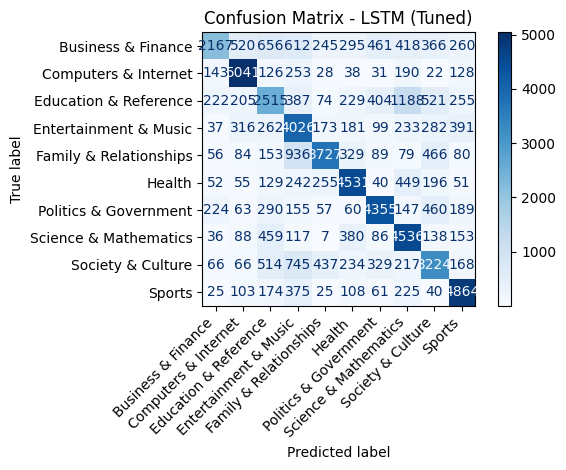


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2167,520,656,612,245,295,461,418,366,260
Computers & Internet,143,5041,126,253,28,38,31,190,22,128
Education & Reference,222,205,2515,387,74,229,404,1188,521,255
Entertainment & Music,37,316,262,4026,173,181,99,233,282,391
Family & Relationships,56,84,153,936,3727,329,89,79,466,80
Health,52,55,129,242,255,4531,40,449,196,51
Politics & Government,224,63,290,155,57,60,4355,147,460,189
Science & Mathematics,36,88,459,117,7,380,86,4536,138,153
Society & Culture,66,66,514,745,437,234,329,217,3224,168



LSTM Tuning Results:


,units,dropout,val_accuracy,val_f1
4,64,0.5,0.6858,0.6832
6,128,0.3,0.6871,0.6827
3,64,0.3,0.6841,0.6820
5,64,0.6,0.6771,0.6756
7,128,0.5,0.6713,0.6720
8,128,0.6,0.6743,0.6696
1,32,0.5,0.6706,0.6674
2,32,0.6,0.6709,0.6664
0,32,0.3,0.6678,0.6659


In [ ]:
#LSTM Tuning
print("\n[5] TUNING LSTM")

baseline_lstm_acc = results['LSTM (Skip-gram)']['accuracy']
baseline_lstm_f1 = results['LSTM (Skip-gram)']['f1_score']

print(f"Baseline Performance:  Acc={baseline_lstm_acc:.4f}, F1={baseline_lstm_f1:.4f}")
print(f"Baseline: units=64, dropout=0.5")

units_options = [32, 64, 128]
dropout_options = [0.3, 0.5, 0.6]

best_lstm_val_f1 = 0
best_lstm_params = {}
lstm_tuning_results = []

for units in units_options:
    for dropout in dropout_options:
        print(f"  Testing: units={units}, dropout={dropout}")

        model_temp = Sequential([
            create_embedding_layer(),
            LSTM(units, return_sequences=False),
            Dropout(dropout),
            Dense(32, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])
        model_temp. compile(optimizer='adam', loss='categorical_crossentropy',
                          metrics=['accuracy'])

        history_temp = model_temp.fit(
            X_train_pad, y_train_cat,
            epochs=20,
            batch_size=64,
            validation_data=(X_val_pad, y_val_cat),
            callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                    restore_best_weights=True)],
            verbose=0
        )

        val_pred_temp = np.argmax(model_temp.predict(X_val_pad, verbose=0), axis=1)
        val_acc = accuracy_score(y_val, val_pred_temp)
        val_f1 = f1_score(y_val, val_pred_temp, average='macro')

        lstm_tuning_results. append({
            'units': units,
            'dropout': dropout,
            'val_accuracy': val_acc,
            'val_f1':  val_f1
        })

        print(f"    Val Acc:  {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_lstm_val_f1:
            best_lstm_val_f1 = val_f1
            best_lstm_params = {'units': units, 'dropout': dropout}
            best_lstm_model = model_temp

print(f"\nBest Hyperparameters: units={best_lstm_params['units']}, dropout={best_lstm_params['dropout']}")
print(f"Validation F1: {best_lstm_val_f1:.4f}")

lstm_tuned_pred = np.argmax(best_lstm_model. predict(X_test_pad, verbose=0), axis=1)
evaluate_model(y_test, lstm_tuned_pred, 'LSTM (Tuned)', results)
plot_confusion_matrix(y_test, lstm_tuned_pred, 'LSTM (Tuned)', label_encoder.classes_)

tuning_results['LSTM'] = {
    'baseline': {'accuracy': baseline_lstm_acc, 'f1': baseline_lstm_f1,
                 'params':  {'units': 64, 'dropout':  0.5}},
    'tuned': {'accuracy':  results['LSTM (Tuned)']['accuracy'],
              'f1': results['LSTM (Tuned)']['f1_score'],
              'params': best_lstm_params}
}

print("\nLSTM Tuning Results:")
lstm_tune_df = pd.DataFrame(lstm_tuning_results).sort_values('val_f1', ascending=False)
display(lstm_tune_df.round(4))


[6] TUNING BIDIRECTIONAL SimpleRNN
Baseline Performance:  Acc=0.6131, F1=0.5972
Baseline: units=64, dropout=0.5
  Testing: units=32, dropout=0.3
    Val Acc: 0.6502, Val F1: 0.6411
  Testing: units=32, dropout=0.5
    Val Acc: 0.6460, Val F1: 0.6408
  Testing: units=32, dropout=0.6
    Val Acc: 0.6552, Val F1: 0.6484
  Testing: units=64, dropout=0.3
    Val Acc: 0.6489, Val F1: 0.6414
  Testing: units=64, dropout=0.5
    Val Acc: 0.6687, Val F1: 0.6637
  Testing: units=64, dropout=0.6
    Val Acc: 0.6764, Val F1: 0.6685
  Testing: units=128, dropout=0.3
    Val Acc: 0.6590, Val F1: 0.6564
  Testing: units=128, dropout=0.5
    Val Acc: 0.6705, Val F1: 0.6658
  Testing: units=128, dropout=0.6
    Val Acc: 0.6652, Val F1: 0.6613

Best Hyperparameters: units=64, dropout=0.6
Validation F1: 0.6685
Model: Bidirectional SimpleRNN (Tuned)


,Metric,Score
0,Accuracy,0.6222
1,F1-Score (Macro),0.6129



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6665,0.3550,0.4632,6000.0000
Computers & Internet,0.7608,0.8337,0.7955,6000.0000
Education & Reference,0.5703,0.2692,0.3657,6000.0000
Entertainment & Music,0.6223,0.5940,0.6078,6000.0000
Family & Relationships,0.6664,0.6149,0.6396,5999.0000
Health,0.4674,0.8368,0.5998,6000.0000
Politics & Government,0.7095,0.6962,0.7028,6000.0000
Science & Mathematics,0.5216,0.7633,0.6198,6000.0000
Society & Culture,0.5501,0.5078,0.5281,6000.0000
Sports,0.8698,0.7515,0.8063,6000.0000


<Figure size 800x600 with 0 Axes>

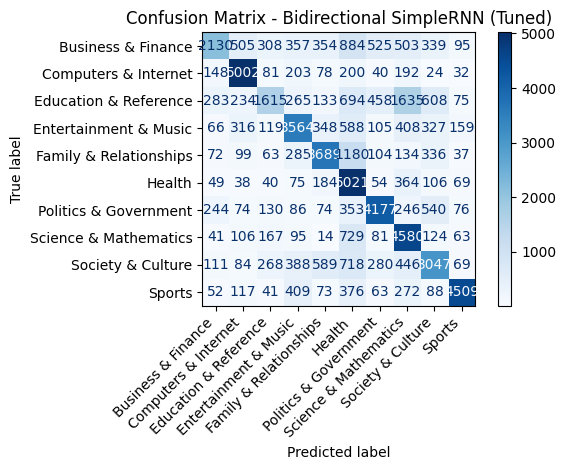


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2130,505,308,357,354,884,525,503,339,95
Computers & Internet,148,5002,81,203,78,200,40,192,24,32
Education & Reference,283,234,1615,265,133,694,458,1635,608,75
Entertainment & Music,66,316,119,3564,348,588,105,408,327,159
Family & Relationships,72,99,63,285,3689,1180,104,134,336,37
Health,49,38,40,75,184,5021,54,364,106,69
Politics & Government,244,74,130,86,74,353,4177,246,540,76
Science & Mathematics,41,106,167,95,14,729,81,4580,124,63
Society & Culture,111,84,268,388,589,718,280,446,3047,69



Bidirectional SimpleRNN Tuning Results:


,units,dropout,val_accuracy,val_f1
5,64,0.6,0.6764,0.6685
7,128,0.5,0.6705,0.6658
4,64,0.5,0.6687,0.6637
8,128,0.6,0.6652,0.6613
6,128,0.3,0.6590,0.6564
2,32,0.6,0.6552,0.6484
3,64,0.3,0.6489,0.6414
0,32,0.3,0.6502,0.6411
1,32,0.5,0.6460,0.6408


In [ ]:
#Bidirectional Simple RNN Tuning
print("\n[6] TUNING BIDIRECTIONAL SimpleRNN")

baseline_bi_rnn_acc = results['Bidirectional SimpleRNN (Skip-gram)']['accuracy']
baseline_bi_rnn_f1 = results['Bidirectional SimpleRNN (Skip-gram)']['f1_score']

print(f"Baseline Performance:  Acc={baseline_bi_rnn_acc:.4f}, F1={baseline_bi_rnn_f1:.4f}")
print(f"Baseline: units=64, dropout=0.5")

units_options = [32, 64, 128]
dropout_options = [0.3, 0.5, 0.6]

best_bi_rnn_val_f1 = 0
best_bi_rnn_params = {}
bi_rnn_tuning_results = []

for units in units_options:
    for dropout in dropout_options:
        print(f"  Testing: units={units}, dropout={dropout}")

        model_temp = Sequential([
            create_embedding_layer(),
            Bidirectional(SimpleRNN(units, return_sequences=False)),
            Dropout(dropout),
            Dense(32, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])
        model_temp. compile(optimizer='adam', loss='categorical_crossentropy',
                          metrics=['accuracy'])

        history_temp = model_temp.fit(
            X_train_pad, y_train_cat,
            epochs=20,
            batch_size=64,
            validation_data=(X_val_pad, y_val_cat),
            callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                    restore_best_weights=True)],
            verbose=0
        )

        val_pred_temp = np.argmax(model_temp.predict(X_val_pad, verbose=0), axis=1)
        val_acc = accuracy_score(y_val, val_pred_temp)
        val_f1 = f1_score(y_val, val_pred_temp, average='macro')

        bi_rnn_tuning_results.append({
            'units':  units,
            'dropout': dropout,
            'val_accuracy': val_acc,
            'val_f1': val_f1
        })

        print(f"    Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_bi_rnn_val_f1:
            best_bi_rnn_val_f1 = val_f1
            best_bi_rnn_params = {'units':  units, 'dropout': dropout}
            best_bi_rnn_model = model_temp

print(f"\nBest Hyperparameters: units={best_bi_rnn_params['units']}, dropout={best_bi_rnn_params['dropout']}")
print(f"Validation F1: {best_bi_rnn_val_f1:.4f}")

bi_rnn_tuned_pred = np.argmax(best_bi_rnn_model. predict(X_test_pad, verbose=0), axis=1)
evaluate_model(y_test, bi_rnn_tuned_pred, 'Bidirectional SimpleRNN (Tuned)', results)
plot_confusion_matrix(y_test, bi_rnn_tuned_pred, 'Bidirectional SimpleRNN (Tuned)', label_encoder.classes_)

tuning_results['Bidirectional SimpleRNN'] = {
    'baseline': {'accuracy': baseline_bi_rnn_acc, 'f1': baseline_bi_rnn_f1,
                 'params': {'units':  64, 'dropout': 0.5}},
    'tuned': {'accuracy': results['Bidirectional SimpleRNN (Tuned)']['accuracy'],
              'f1':  results['Bidirectional SimpleRNN (Tuned)']['f1_score'],
              'params':  best_bi_rnn_params}
}

print("\nBidirectional SimpleRNN Tuning Results:")
bi_rnn_tune_df = pd.DataFrame(bi_rnn_tuning_results).sort_values('val_f1', ascending=False)
display(bi_rnn_tune_df.round(4))


[7] TUNING BIDIRECTIONAL GRU
Baseline Performance:  Acc=0.6630, F1=0.6615
Baseline: units=64, dropout=0.5
  Testing: units=32, dropout=0.3
    Val Acc: 0.7038, Val F1: 0.6997
  Testing: units=32, dropout=0.5
    Val Acc: 0.6958, Val F1: 0.6911
  Testing: units=32, dropout=0.6
    Val Acc: 0.6981, Val F1: 0.6935
  Testing: units=64, dropout=0.3
    Val Acc: 0.7049, Val F1: 0.6994
  Testing: units=64, dropout=0.5
    Val Acc: 0.7070, Val F1: 0.7025
  Testing: units=64, dropout=0.6
    Val Acc: 0.7003, Val F1: 0.6939
  Testing: units=128, dropout=0.3
    Val Acc: 0.7073, Val F1: 0.7036
  Testing: units=128, dropout=0.5
    Val Acc: 0.7075, Val F1: 0.7034
  Testing: units=128, dropout=0.6
    Val Acc: 0.7039, Val F1: 0.6990

Best Hyperparameters: units=128, dropout=0.3
Validation F1: 0.7036
Model: Bidirectional GRU (Tuned)


,Metric,Score
0,Accuracy,0.6667
1,F1-Score (Macro),0.6629



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.7258,0.3785,0.4975,6000.0000
Computers & Internet,0.7856,0.8595,0.8209,6000.0000
Education & Reference,0.5808,0.4027,0.4756,6000.0000
Entertainment & Music,0.5722,0.6820,0.6223,6000.0000
Family & Relationships,0.7784,0.6211,0.6909,5999.0000
Health,0.7318,0.7737,0.7522,6000.0000
Politics & Government,0.6410,0.8062,0.7142,6000.0000
Science & Mathematics,0.7108,0.6853,0.6978,6000.0000
Society & Culture,0.4438,0.6670,0.5330,6000.0000
Sports,0.8608,0.7913,0.8246,6000.0000


<Figure size 800x600 with 0 Axes>

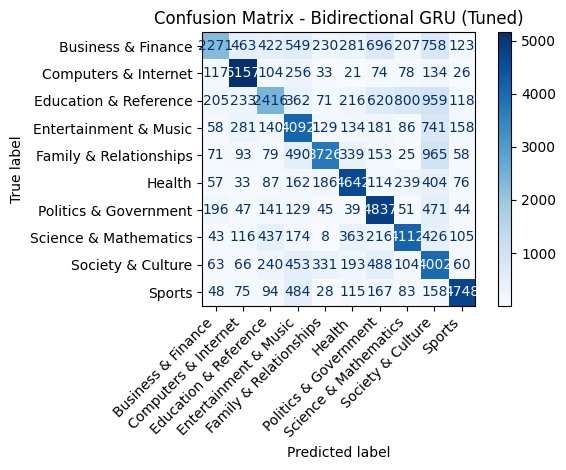


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2271,463,422,549,230,281,696,207,758,123
Computers & Internet,117,5157,104,256,33,21,74,78,134,26
Education & Reference,205,233,2416,362,71,216,620,800,959,118
Entertainment & Music,58,281,140,4092,129,134,181,86,741,158
Family & Relationships,71,93,79,490,3726,339,153,25,965,58
Health,57,33,87,162,186,4642,114,239,404,76
Politics & Government,196,47,141,129,45,39,4837,51,471,44
Science & Mathematics,43,116,437,174,8,363,216,4112,426,105
Society & Culture,63,66,240,453,331,193,488,104,4002,60



Bidirectional GRU Tuning Results:


,units,dropout,val_accuracy,val_f1
6,128,0.3,0.7073,0.7036
7,128,0.5,0.7075,0.7034
4,64,0.5,0.7070,0.7025
0,32,0.3,0.7038,0.6997
3,64,0.3,0.7049,0.6994
8,128,0.6,0.7039,0.6990
5,64,0.6,0.7003,0.6939
2,32,0.6,0.6981,0.6935
1,32,0.5,0.6958,0.6911


In [ ]:
#Bidirectional GRU Tuning
print("\n[7] TUNING BIDIRECTIONAL GRU")

baseline_bi_gru_acc = results['Bidirectional GRU (Skip-gram)']['accuracy']
baseline_bi_gru_f1 = results['Bidirectional GRU (Skip-gram)']['f1_score']

print(f"Baseline Performance:  Acc={baseline_bi_gru_acc:.4f}, F1={baseline_bi_gru_f1:.4f}")
print(f"Baseline: units=64, dropout=0.5")

units_options = [32, 64, 128]
dropout_options = [0.3, 0.5, 0.6]

best_bi_gru_val_f1 = 0
best_bi_gru_params = {}
bi_gru_tuning_results = []

for units in units_options:
    for dropout in dropout_options:
        print(f"  Testing: units={units}, dropout={dropout}")

        model_temp = Sequential([
            create_embedding_layer(),
            Bidirectional(GRU(units, return_sequences=False)),
            Dropout(dropout),
            Dense(32, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])
        model_temp.compile(optimizer='adam', loss='categorical_crossentropy',
                          metrics=['accuracy'])

        history_temp = model_temp.fit(
            X_train_pad, y_train_cat,
            epochs=20,
            batch_size=64,
            validation_data=(X_val_pad, y_val_cat),
            callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                    restore_best_weights=True)],
            verbose=0
        )

        val_pred_temp = np. argmax(model_temp.predict(X_val_pad, verbose=0), axis=1)
        val_acc = accuracy_score(y_val, val_pred_temp)
        val_f1 = f1_score(y_val, val_pred_temp, average='macro')

        bi_gru_tuning_results.append({
            'units': units,
            'dropout': dropout,
            'val_accuracy': val_acc,
            'val_f1': val_f1
        })

        print(f"    Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_bi_gru_val_f1:
            best_bi_gru_val_f1 = val_f1
            best_bi_gru_params = {'units': units, 'dropout': dropout}
            best_bi_gru_model = model_temp

print(f"\nBest Hyperparameters: units={best_bi_gru_params['units']}, dropout={best_bi_gru_params['dropout']}")
print(f"Validation F1: {best_bi_gru_val_f1:.4f}")

bi_gru_tuned_pred = np.argmax(best_bi_gru_model.predict(X_test_pad, verbose=0), axis=1)
evaluate_model(y_test, bi_gru_tuned_pred, 'Bidirectional GRU (Tuned)', results)
plot_confusion_matrix(y_test, bi_gru_tuned_pred, 'Bidirectional GRU (Tuned)', label_encoder.classes_)

tuning_results['Bidirectional GRU'] = {
    'baseline':  {'accuracy': baseline_bi_gru_acc, 'f1': baseline_bi_gru_f1,
                 'params': {'units': 64, 'dropout': 0.5}},
    'tuned':  {'accuracy': results['Bidirectional GRU (Tuned)']['accuracy'],
              'f1': results['Bidirectional GRU (Tuned)']['f1_score'],
              'params': best_bi_gru_params}
}

print("\nBidirectional GRU Tuning Results:")
bi_gru_tune_df = pd. DataFrame(bi_gru_tuning_results).sort_values('val_f1', ascending=False)
display(bi_gru_tune_df.round(4))


[8] TUNING BIDIRECTIONAL LSTM
Baseline Performance: Acc=0.6579, F1=0.6517
Baseline: units=64, dropout=0.5
  Testing: units=32, dropout=0.3
    Val Acc: 0.6998, Val F1: 0.6943
  Testing: units=32, dropout=0.5
    Val Acc: 0.6936, Val F1: 0.6876
  Testing: units=32, dropout=0.6
    Val Acc: 0.6923, Val F1: 0.6894
  Testing: units=64, dropout=0.3
    Val Acc: 0.6958, Val F1: 0.6909
  Testing: units=64, dropout=0.5
    Val Acc: 0.6969, Val F1: 0.6935
  Testing: units=64, dropout=0.6
    Val Acc: 0.6974, Val F1: 0.6923
  Testing: units=128, dropout=0.3
    Val Acc: 0.6986, Val F1: 0.6947
  Testing: units=128, dropout=0.5
    Val Acc: 0.6920, Val F1: 0.6870
  Testing: units=128, dropout=0.6
    Val Acc: 0.6964, Val F1: 0.6936

Best Hyperparameters: units=128, dropout=0.3
Validation F1: 0.6947
Model: Bidirectional LSTM (Tuned)


,Metric,Score
0,Accuracy,0.6557
1,F1-Score (Macro),0.6532



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.7035,0.3832,0.4961,6000.0000
Computers & Internet,0.7583,0.8710,0.8107,6000.0000
Education & Reference,0.5989,0.3688,0.4565,6000.0000
Entertainment & Music,0.6104,0.6385,0.6241,6000.0000
Family & Relationships,0.7947,0.5588,0.6562,5999.0000
Health,0.7012,0.7900,0.7429,6000.0000
Politics & Government,0.6815,0.7862,0.7301,6000.0000
Science & Mathematics,0.6723,0.7278,0.6989,6000.0000
Society & Culture,0.3963,0.7060,0.5076,6000.0000
Sports,0.9115,0.7265,0.8086,6000.0000


<Figure size 800x600 with 0 Axes>

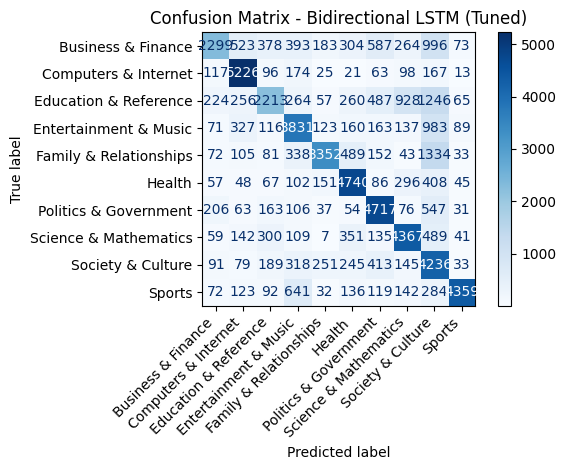


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2299,523,378,393,183,304,587,264,996,73
Computers & Internet,117,5226,96,174,25,21,63,98,167,13
Education & Reference,224,256,2213,264,57,260,487,928,1246,65
Entertainment & Music,71,327,116,3831,123,160,163,137,983,89
Family & Relationships,72,105,81,338,3352,489,152,43,1334,33
Health,57,48,67,102,151,4740,86,296,408,45
Politics & Government,206,63,163,106,37,54,4717,76,547,31
Science & Mathematics,59,142,300,109,7,351,135,4367,489,41
Society & Culture,91,79,189,318,251,245,413,145,4236,33



Bidirectional LSTM Tuning Results:


,units,dropout,val_accuracy,val_f1
6,128,0.3,0.6986,0.6947
0,32,0.3,0.6998,0.6943
8,128,0.6,0.6964,0.6936
4,64,0.5,0.6969,0.6935
5,64,0.6,0.6974,0.6923
3,64,0.3,0.6958,0.6909
2,32,0.6,0.6923,0.6894
1,32,0.5,0.6936,0.6876
7,128,0.5,0.6920,0.6870


In [ ]:
#Bidirectional LSTM Tuning
print("\n[8] TUNING BIDIRECTIONAL LSTM")

baseline_bi_lstm_acc = results['Bidirectional LSTM (Skip-gram)']['accuracy']
baseline_bi_lstm_f1 = results['Bidirectional LSTM (Skip-gram)']['f1_score']

print(f"Baseline Performance: Acc={baseline_bi_lstm_acc:.4f}, F1={baseline_bi_lstm_f1:.4f}")
print(f"Baseline: units=64, dropout=0.5")

units_options = [32, 64, 128]
dropout_options = [0.3, 0.5, 0.6]

best_bi_lstm_val_f1 = 0
best_bi_lstm_params = {}
bi_lstm_tuning_results = []

for units in units_options:
    for dropout in dropout_options:
        print(f"  Testing: units={units}, dropout={dropout}")

        model_temp = Sequential([
            create_embedding_layer(),
            Bidirectional(LSTM(units, return_sequences=False)),
            Dropout(dropout),
            Dense(32, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])
        model_temp.compile(optimizer='adam', loss='categorical_crossentropy',
                          metrics=['accuracy'])

        history_temp = model_temp. fit(
            X_train_pad, y_train_cat,
            epochs=20,
            batch_size=64,
            validation_data=(X_val_pad, y_val_cat),
            callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                    restore_best_weights=True)],
            verbose=0
        )

        val_pred_temp = np.argmax(model_temp.predict(X_val_pad, verbose=0), axis=1)
        val_acc = accuracy_score(y_val, val_pred_temp)
        val_f1 = f1_score(y_val, val_pred_temp, average='macro')

        bi_lstm_tuning_results.append({
            'units': units,
            'dropout': dropout,
            'val_accuracy': val_acc,
            'val_f1': val_f1
        })

        print(f"    Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_bi_lstm_val_f1:
            best_bi_lstm_val_f1 = val_f1
            best_bi_lstm_params = {'units': units, 'dropout': dropout}
            best_bi_lstm_model = model_temp

print(f"\nBest Hyperparameters: units={best_bi_lstm_params['units']}, dropout={best_bi_lstm_params['dropout']}")
print(f"Validation F1: {best_bi_lstm_val_f1:.4f}")

bi_lstm_tuned_pred = np.argmax(best_bi_lstm_model.predict(X_test_pad, verbose=0), axis=1)
evaluate_model(y_test, bi_lstm_tuned_pred, 'Bidirectional LSTM (Tuned)', results)
plot_confusion_matrix(y_test, bi_lstm_tuned_pred, 'Bidirectional LSTM (Tuned)', label_encoder.classes_)

tuning_results['Bidirectional LSTM'] = {
    'baseline': {'accuracy': baseline_bi_lstm_acc, 'f1': baseline_bi_lstm_f1,
                 'params': {'units':  64, 'dropout': 0.5}},
    'tuned': {'accuracy': results['Bidirectional LSTM (Tuned)']['accuracy'],
              'f1': results['Bidirectional LSTM (Tuned)']['f1_score'],
              'params': best_bi_lstm_params}
}

print("\nBidirectional LSTM Tuning Results:")
bi_lstm_tune_df = pd.DataFrame(bi_lstm_tuning_results).sort_values('val_f1', ascending=False)
display(bi_lstm_tune_df.round(4))



[9] TUNING DNN (Skip-gram)
Baseline Performance: Acc=0.6579, F1=0.6568
Baseline:  arch=[128,64], dropout=[0.5,0.3]
  Testing: dense=small, dropout=low
    Val Acc: 0.6736, Val F1: 0.6688
  Testing: dense=small, dropout=baseline
    Val Acc: 0.6740, Val F1: 0.6699
  Testing: dense=small, dropout=high
    Val Acc: 0.6652, Val F1: 0.6609
  Testing: dense=baseline, dropout=low
    Val Acc: 0.6826, Val F1: 0.6816
  Testing: dense=baseline, dropout=baseline
    Val Acc: 0.6802, Val F1: 0.6796
  Testing: dense=baseline, dropout=high
    Val Acc: 0.6775, Val F1: 0.6733
  Testing: dense=large, dropout=low
    Val Acc: 0.6794, Val F1: 0.6763
  Testing: dense=large, dropout=baseline
    Val Acc: 0.6796, Val F1: 0.6793
  Testing: dense=large, dropout=high
    Val Acc: 0.6815, Val F1: 0.6788

Best Hyperparameters:
  Dense: baseline [128, 64]
  Dropout: low [0.3, 0.2]
  Validation F1: 0.6816
Model: DNN (Skip-gram) - Tuned


,Metric,Score
0,Accuracy,0.6615
1,F1-Score (Macro),0.6614



Classification Report


,precision,recall,f1-score,support
Business & Finance,0.6392,0.4087,0.4986,6000.0000
Computers & Internet,0.7902,0.8400,0.8143,6000.0000
Education & Reference,0.4188,0.5297,0.4678,6000.0000
Entertainment & Music,0.5878,0.6623,0.6228,6000.0000
Family & Relationships,0.7104,0.6759,0.6927,5999.0000
Health,0.7437,0.7473,0.7455,6000.0000
Politics & Government,0.6872,0.7572,0.7205,6000.0000
Science & Mathematics,0.7215,0.6547,0.6865,6000.0000
Society & Culture,0.5410,0.5473,0.5442,6000.0000
Sports,0.8524,0.7918,0.8210,6000.0000


<Figure size 800x600 with 0 Axes>

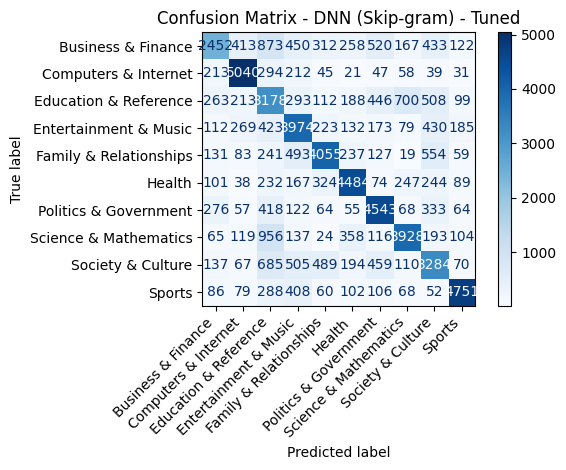


Confusion Matrix (Table Format)


Predicted,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Actual,,,,,,,,,,
Business & Finance,2452,413,873,450,312,258,520,167,433,122
Computers & Internet,213,5040,294,212,45,21,47,58,39,31
Education & Reference,263,213,3178,293,112,188,446,700,508,99
Entertainment & Music,112,269,423,3974,223,132,173,79,430,185
Family & Relationships,131,83,241,493,4055,237,127,19,554,59
Health,101,38,232,167,324,4484,74,247,244,89
Politics & Government,276,57,418,122,64,55,4543,68,333,64
Science & Mathematics,65,119,956,137,24,358,116,3928,193,104
Society & Culture,137,67,685,505,489,194,459,110,3284,70



DNN (Skip-gram) Tuning Results:


,dense,dropout,val_accuracy,val_f1
3,baseline,low,0.6826,0.6816
4,baseline,baseline,0.6802,0.6796
7,large,baseline,0.6796,0.6793
8,large,high,0.6815,0.6788
6,large,low,0.6794,0.6763
5,baseline,high,0.6775,0.6733
1,small,baseline,0.6740,0.6699
0,small,low,0.6736,0.6688
2,small,high,0.6652,0.6609


In [ ]:
#DNN Skipgram Tuning
print("\n[9] TUNING DNN (Skip-gram)")

baseline_dnn_sg_acc = results['DNN (Skip-gram)']['accuracy']
baseline_dnn_sg_f1 = results['DNN (Skip-gram)']['f1_score']

print(f"Baseline Performance: Acc={baseline_dnn_sg_acc:.4f}, F1={baseline_dnn_sg_f1:.4f}")
print(f"Baseline:  arch=[128,64], dropout=[0.5,0.3]")

dense_configs = [
    ([64, 32], "small"),
    ([128, 64], "baseline"),
    ([256, 128], "large")
]

dropout_configs = [
    ([0.3, 0.2], "low"),
    ([0.5, 0.3], "baseline"),
    ([0.6, 0.4], "high")
]

best_dnn_sg_val_f1 = 0
best_dnn_sg_params = {}
dnn_sg_tuning_results = []

for dense_list, dense_name in dense_configs:
    for dropout_list, dropout_name in dropout_configs:
        print(f"  Testing: dense={dense_name}, dropout={dropout_name}")

        model_temp = Sequential([
            create_embedding_layer(),
            GlobalAveragePooling1D(),
            Dense(dense_list[0], activation='relu'),
            Dropout(dropout_list[0]),
            Dense(dense_list[1], activation='relu'),
            Dropout(dropout_list[1]),
            Dense(num_classes, activation='softmax')
        ])
        model_temp.compile(optimizer='adam', loss='categorical_crossentropy',
                          metrics=['accuracy'])

        history_temp = model_temp. fit(
            X_train_pad, y_train_cat,
            epochs=20,
            batch_size=64,
            validation_data=(X_val_pad, y_val_cat),
            callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                    restore_best_weights=True)],
            verbose=0
        )

        val_pred_temp = np.argmax(model_temp.predict(X_val_pad, verbose=0), axis=1)
        val_acc = accuracy_score(y_val, val_pred_temp)
        val_f1 = f1_score(y_val, val_pred_temp, average='macro')

        dnn_sg_tuning_results. append({
            'dense': dense_name,
            'dropout': dropout_name,
            'val_accuracy': val_acc,
            'val_f1': val_f1
        })

        print(f"    Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_dnn_sg_val_f1:
            best_dnn_sg_val_f1 = val_f1
            best_dnn_sg_params = {
                'dense':  dense_list,
                'dense_name': dense_name,
                'dropout': dropout_list,
                'dropout_name': dropout_name
            }
            best_dnn_sg_model = model_temp

print(f"\nBest Hyperparameters:")
print(f"  Dense: {best_dnn_sg_params['dense_name']} {best_dnn_sg_params['dense']}")
print(f"  Dropout: {best_dnn_sg_params['dropout_name']} {best_dnn_sg_params['dropout']}")
print(f"  Validation F1: {best_dnn_sg_val_f1:.4f}")

dnn_sg_tuned_pred = np.argmax(best_dnn_sg_model.predict(X_test_pad, verbose=0), axis=1)
evaluate_model(y_test, dnn_sg_tuned_pred, 'DNN (Skip-gram) - Tuned', results)
plot_confusion_matrix(y_test, dnn_sg_tuned_pred, 'DNN (Skip-gram) - Tuned', label_encoder. classes_)

tuning_results['DNN (Skip-gram)'] = {
    'baseline': {'accuracy': baseline_dnn_sg_acc, 'f1': baseline_dnn_sg_f1,
                 'params': {'dense':  [128, 64], 'dropout': [0.5, 0.3]}},
    'tuned':  {'accuracy': results['DNN (Skip-gram) - Tuned']['accuracy'],
              'f1': results['DNN (Skip-gram) - Tuned']['f1_score'],
              'params': best_dnn_sg_params}
}

print("\nDNN (Skip-gram) Tuning Results:")
dnn_sg_tune_df = pd. DataFrame(dnn_sg_tuning_results).sort_values('val_f1', ascending=False)
display(dnn_sg_tune_df.round(4))

HYPERPARAMETER TUNING SUMMARY

Baseline vs Tuned Performance:


,Model,Baseline Accuracy,Tuned Accuracy,Acc Improvement (%),Baseline F1,Tuned F1,F1 Improvement (%)
3,GRU,0.6642,0.6718,0.76,0.6619,0.6655,0.36
6,Bidirectional GRU,0.6630,0.6667,0.37,0.6615,0.6629,0.14
8,DNN (Skip-gram),0.6579,0.6615,0.36,0.6568,0.6614,0.46
0,Logistic Regression,0.6582,0.6584,0.02,0.6554,0.6551,-0.03
7,Bidirectional LSTM,0.6579,0.6557,-0.22,0.6517,0.6532,0.15
1,DNN (TF-IDF),0.6554,0.6556,0.02,0.6490,0.6504,0.14
4,LSTM,0.6278,0.6498,2.20,0.6244,0.6437,1.93
5,Bidirectional SimpleRNN,0.6131,0.6222,0.91,0.5972,0.6129,1.57
2,SimpleRNN,0.1782,0.1983,2.01,0.1106,0.1247,1.41


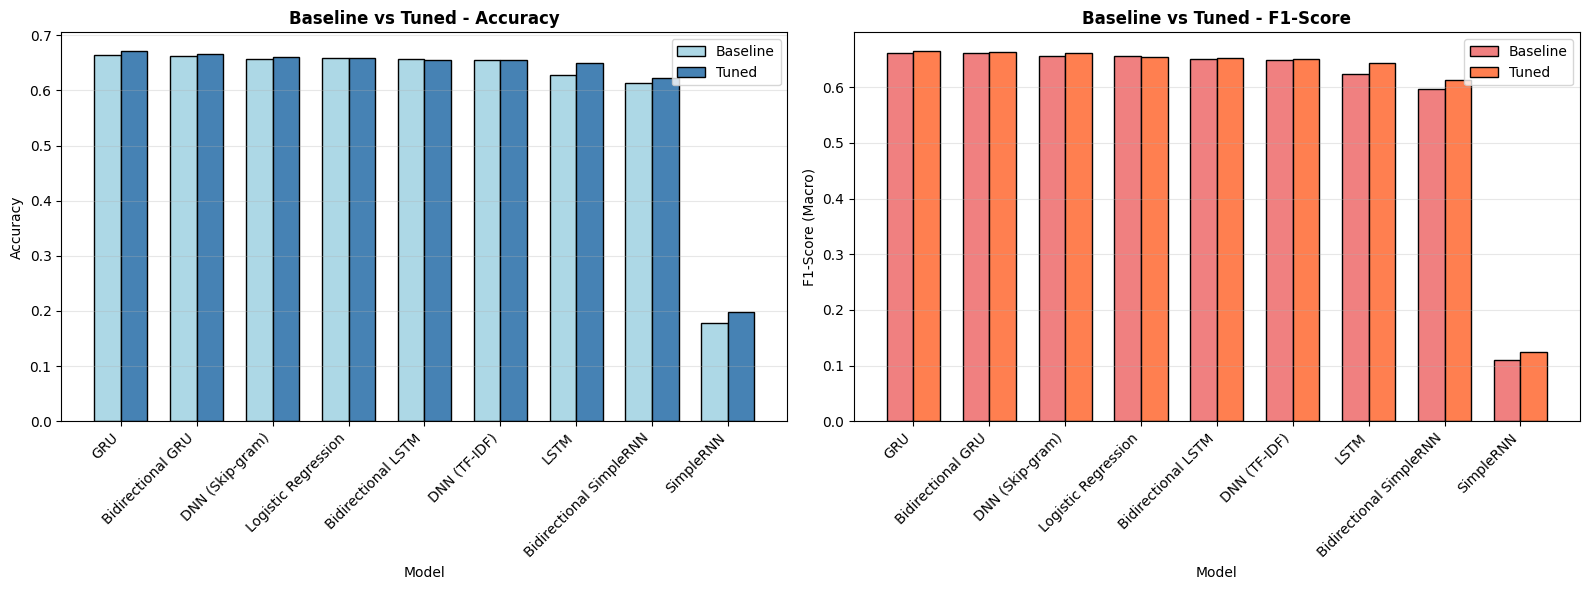


Improvement Analysis


,Metric,Value (%)
0,Average Accuracy Improvement,0.71
1,Average F1-Score Improvement,0.68



Most Improved Model


,Attribute,Value
0,Model,LSTM
1,Baseline F1,0.6244
2,Tuned F1,0.6437
3,Improvement (%),1.93



Best Model After Tuning


,Attribute,Value
0,Model,GRU
1,Test Accuracy,0.6718
2,Test F1-Score,0.6655



FINAL SELECTED HYPERPARAMETERS FOR EACH MODEL


,Model,Baseline Params,Tuned Params,F1 Improvement (%)
4,LSTM,"{'units': 64, 'dropout': 0.5}","{'units': 64, 'dropout': 0.5}",1.93
5,Bidirectional SimpleRNN,"{'units': 64, 'dropout': 0.5}","{'units': 64, 'dropout': 0.6}",1.57
2,SimpleRNN,"{'units': 64, 'dropout': 0.5}","{'units': 64, 'dropout': 0.6}",1.41
8,DNN (Skip-gram),"{'dense': [128, 64], 'dropout': [0.5, 0.3]}","{'dense': [128, 64], 'dense_name': 'baseline',...",0.46
3,GRU,"{'units': 64, 'dropout': 0.5}","{'units': 128, 'dropout': 0.3}",0.36
7,Bidirectional LSTM,"{'units': 64, 'dropout': 0.5}","{'units': 128, 'dropout': 0.3}",0.15
1,DNN (TF-IDF),"{'dropout': [0.5, 0.3, 0.2], 'batch': 64}","{'dropout': [0.6, 0.4, 0.3], 'dropout_name': '...",0.14
6,Bidirectional GRU,"{'units': 64, 'dropout': 0.5}","{'units': 128, 'dropout': 0.3}",0.14
0,Logistic Regression,"{'C': 1.0, 'solver': 'lbfgs'}","{'C': 0.5, 'solver': 'lbfgs'}",-0.03


In [ ]:
#Hyperparameter Tuning Summary
print("HYPERPARAMETER TUNING SUMMARY")

# Create comparison table
tuning_comparison = []

for model_name, data in tuning_results.items():
    baseline_acc = data['baseline']['accuracy']
    tuned_acc = data['tuned']['accuracy']
    baseline_f1 = data['baseline']['f1']
    tuned_f1 = data['tuned']['f1']

    improvement_acc = (tuned_acc - baseline_acc) * 100
    improvement_f1 = (tuned_f1 - baseline_f1) * 100

    tuning_comparison. append({
        'Model': model_name,
        'Baseline Accuracy': round(baseline_acc, 4),
        'Tuned Accuracy': round(tuned_acc, 4),
        'Acc Improvement (%)': round(improvement_acc, 2),
        'Baseline F1': round(baseline_f1, 4),
        'Tuned F1': round(tuned_f1, 4),
        'F1 Improvement (%)': round(improvement_f1, 2)
    })

tuning_comparison_df = pd. DataFrame(tuning_comparison)
tuning_comparison_df = tuning_comparison_df.sort_values('Tuned F1', ascending=False)

print("\nBaseline vs Tuned Performance:")
display(tuning_comparison_df)

# Visualize improvements
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(tuning_comparison_df))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, tuning_comparison_df['Baseline Accuracy'], width,
           label='Baseline', color='lightblue', edgecolor='black')
axes[0]. bar(x + width/2, tuning_comparison_df['Tuned Accuracy'], width,
           label='Tuned', color='steelblue', edgecolor='black')
axes[0]. set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0]. set_title('Baseline vs Tuned - Accuracy', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tuning_comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0]. grid(axis='y', alpha=0.3)

# F1-Score comparison
axes[1].bar(x - width/2, tuning_comparison_df['Baseline F1'], width,
           label='Baseline', color='lightcoral', edgecolor='black')
axes[1].bar(x + width/2, tuning_comparison_df['Tuned F1'], width,
           label='Tuned', color='coral', edgecolor='black')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_title('Baseline vs Tuned - F1-Score', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tuning_comparison_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Improvement analysis
print("\nImprovement Analysis")
improvement_df = pd.DataFrame({
    'Metric': ['Average Accuracy Improvement', 'Average F1-Score Improvement'],
    'Value (%)': [
        round(tuning_comparison_df['Acc Improvement (%)'].mean(), 2),
        round(tuning_comparison_df['F1 Improvement (%)'].mean(), 2)
    ]
})
display(improvement_df)

# Most improved model
most_improved_idx = tuning_comparison_df['F1 Improvement (%)'].idxmax()
most_improved = tuning_comparison_df.loc[most_improved_idx]

print("\nMost Improved Model")
most_improved_df = pd.DataFrame({
    'Attribute': ['Model', 'Baseline F1', 'Tuned F1', 'Improvement (%)'],
    'Value': [
        most_improved['Model'],
        most_improved['Baseline F1'],
        most_improved['Tuned F1'],
        most_improved['F1 Improvement (%)']
    ]
})
display(most_improved_df)

# Best overall model after tuning
best_tuned = tuning_comparison_df.iloc[0]

print("\nBest Model After Tuning")
best_tuned_df = pd.DataFrame({
    'Attribute': ['Model', 'Test Accuracy', 'Test F1-Score'],
    'Value':  [
        best_tuned['Model'],
        best_tuned['Tuned Accuracy'],
        best_tuned['Tuned F1']
    ]
})
display(best_tuned_df)

# Final hyperparameters table
print("\n" + "="*80)
print("FINAL SELECTED HYPERPARAMETERS FOR EACH MODEL")
print("="*80)

final_params_list = []
for model_name, data in tuning_results.items():
    final_params_list.append({
        'Model': model_name,
        'Baseline Params': str(data['baseline']['params']),
        'Tuned Params': str(data['tuned']['params']),
        'F1 Improvement (%)': round((data['tuned']['f1'] - data['baseline']['f1']) * 100, 2)
    })

final_params_df = pd. DataFrame(final_params_list)
final_params_df = final_params_df.sort_values('F1 Improvement (%)', ascending=False)
display(final_params_df)


Result Comparison and Analysis

In [ ]:
# Create results DataFrame (includes both baseline and tuned models)
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'F1-Score (Macro)': [results[m]['f1_score'] for m in results]
})

results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df['Rank'] = range(1, len(results_df) + 1)
results_df = results_df[['Rank', 'Model', 'Accuracy', 'F1-Score (Macro)']]
results_df['Accuracy'] = results_df['Accuracy'].round(4)
results_df['F1-Score (Macro)'] = results_df['F1-Score (Macro)'].round(4)

print("ALL MODELS PERFORMANCE SUMMARY (Baseline + Tuned)")
display(results_df)

ALL MODELS PERFORMANCE SUMMARY (Baseline + Tuned)


,Rank,Model,Accuracy,F1-Score (Macro)
0,1,GRU (Tuned),0.6718,0.6655
1,2,Bidirectional GRU (Tuned),0.6667,0.6629
2,3,GRU (Skip-gram),0.6642,0.6619
3,4,Bidirectional GRU (Skip-gram),0.6630,0.6615
4,5,DNN (Skip-gram) - Tuned,0.6615,0.6614
5,6,Logistic Regression (Tuned),0.6584,0.6551
6,7,Logistic Regression (TF-IDF),0.6582,0.6554
7,8,DNN (Skip-gram),0.6579,0.6568
8,9,Bidirectional LSTM (Skip-gram),0.6579,0.6517
9,10,Bidirectional LSTM (Tuned),0.6557,0.6532


In [ ]:
# Best and Worst Models (from ALL models including tuned)
best_model = results_df.iloc[0]['Model']
worst_model = results_df.iloc[-1]['Model']

print("\nBest and Worst Performing Models (Overall)")
best_worst_df = pd.DataFrame({
    'Category': ['Best Performing Model', 'Worst Performing Model'],
    'Model': [best_model, worst_model],
    'Accuracy': [results_df.iloc[0]['Accuracy'], results_df.iloc[-1]['Accuracy']],
    'F1-Score (Macro)': [results_df.iloc[0]['F1-Score (Macro)'], results_df.iloc[-1]['F1-Score (Macro)']]
})
display(best_worst_df)


Best and Worst Performing Models (Overall)


,Category,Model,Accuracy,F1-Score (Macro)
0,Best Performing Model,GRU (Tuned),0.6718,0.6655
1,Worst Performing Model,SimpleRNN (Skip-gram),0.1782,0.1106


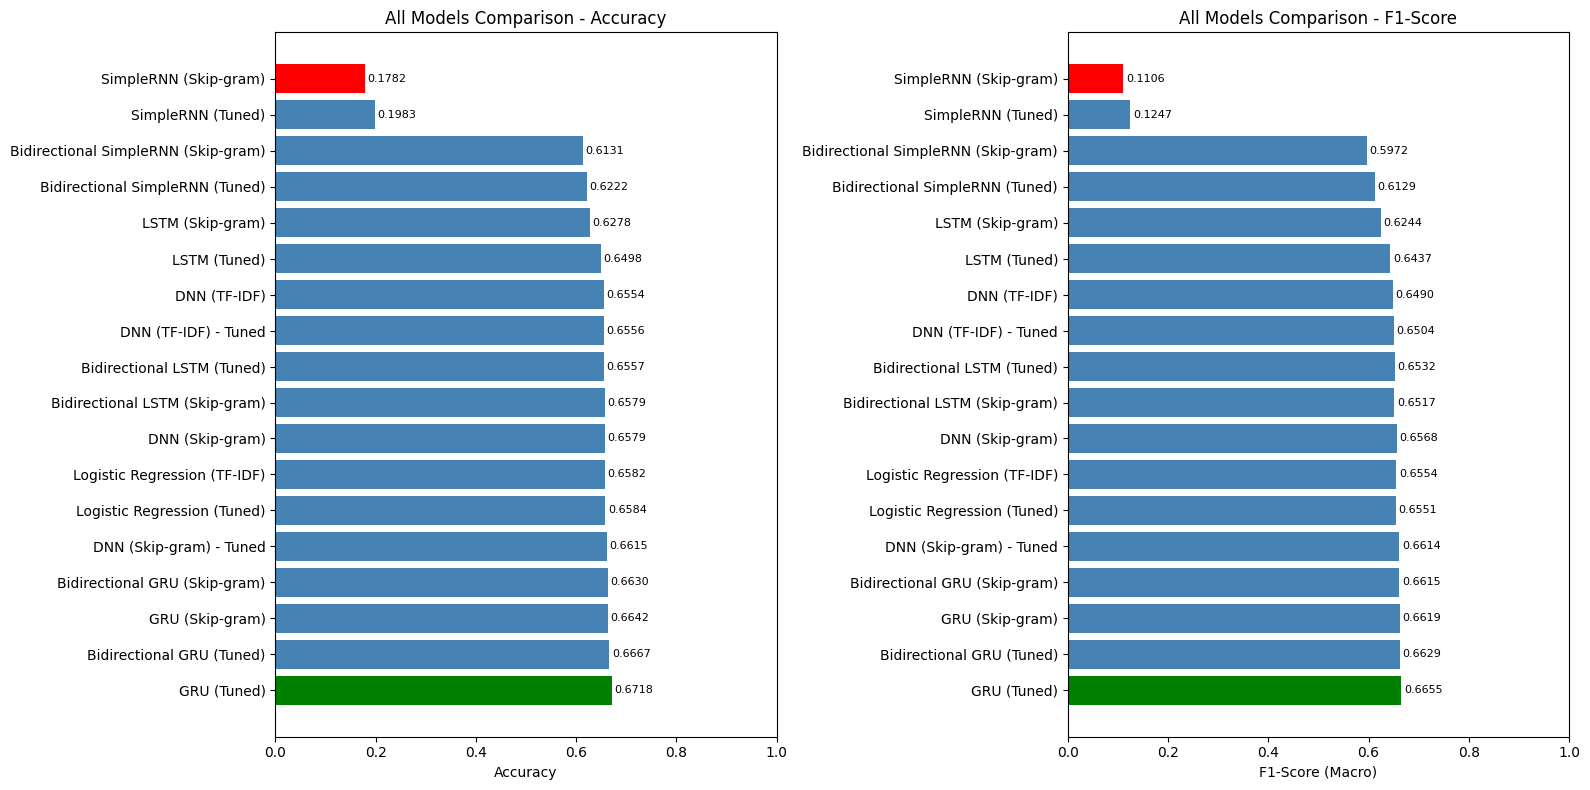

In [ ]:
# Visualization - Bar Plot
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
colors = ['green' if m == best_model else 'red' if m == worst_model else 'steelblue'
          for m in results_df['Model']]
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('All Models Comparison - Accuracy')
plt.xlim(0, 1)
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(acc + 0.005, bar.get_y() + bar.get_height()/2, f'{acc:.4f}',
             va='center', fontsize=8)

plt.subplot(1, 2, 2)
bars = plt.barh(results_df['Model'], results_df['F1-Score (Macro)'], color=colors)
plt.xlabel('F1-Score (Macro)')
plt.title('All Models Comparison - F1-Score')
plt.xlim(0, 1)
for bar, f1 in zip(bars, results_df['F1-Score (Macro)']):
    plt.text(f1 + 0.005, bar.get_y() + bar.get_height()/2, f'{f1:.4f}',
             va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
print("ML MODEL vs BEST NN MODEL COMPARISON")

# Find the best ML model (baseline or tuned Logistic Regression)
ml_models = [m for m in results if 'Logistic Regression' in m]
best_ml = max(ml_models, key=lambda x:  results[x]['accuracy'])
best_ml_acc = results[best_ml]['accuracy']
best_ml_f1 = results[best_ml]['f1_score']

# Find best NN model (excluding Logistic Regression)
nn_models = [m for m in results if 'Logistic Regression' not in m]
best_nn = max(nn_models, key=lambda x:  results[x]['accuracy'])
best_nn_acc = results[best_nn]['accuracy']
best_nn_f1 = results[best_nn]['f1_score']

# Calculate differences
acc_diff = best_nn_acc - best_ml_acc
f1_diff = best_nn_f1 - best_ml_f1

# ML vs NN Comparison Table
print("\nModel Performance Comparison")
ml_vs_nn_df = pd.DataFrame({
    'Metric': ['Model Name', 'Accuracy', 'F1-Score (Macro)'],
    'Best ML Model': [best_ml, round(best_ml_acc, 4), round(best_ml_f1, 4)],
    'Best NN Model': [best_nn, round(best_nn_acc, 4), round(best_nn_f1, 4)],
    'Difference (NN - ML)': ['-', f'{acc_diff:+.4f}', f'{f1_diff:+.4f}']
})
display(ml_vs_nn_df)

ML MODEL vs BEST NN MODEL COMPARISON

Model Performance Comparison


,Metric,Best ML Model,Best NN Model,Difference (NN - ML)
0,Model Name,Logistic Regression (Tuned),GRU (Tuned),-
1,Accuracy,0.6584,0.6718,+0.0134
2,F1-Score (Macro),0.6551,0.6655,+0.0104


In [ ]:
# Conclusion Table
print("\nConclusion")
if acc_diff > 0:
    winner = best_nn
    loser = best_ml
    diff_pct = acc_diff * 100
else:
    winner = best_ml
    loser = best_nn
    diff_pct = abs(acc_diff) * 100

conclusion_df = pd.DataFrame({
    'Aspect': ['Winner', 'Runner-up', 'Accuracy Difference', 'F1-Score Difference', 'Conclusion'],
    'Details': [
        winner,
        loser,
        f'{abs(acc_diff):.4f} ({diff_pct:.2f}%)',
        f'{abs(f1_diff):.4f}',
        f'{winner} outperforms {loser} by {diff_pct:.2f}% in accuracy'
    ]
})
display(conclusion_df)


Conclusion


,Aspect,Details
0,Winner,GRU (Tuned)
1,Runner-up,Logistic Regression (Tuned)
2,Accuracy Difference,0.0134 (1.34%)
3,F1-Score Difference,0.0104
4,Conclusion,GRU (Tuned) outperforms Logistic Regression (T...


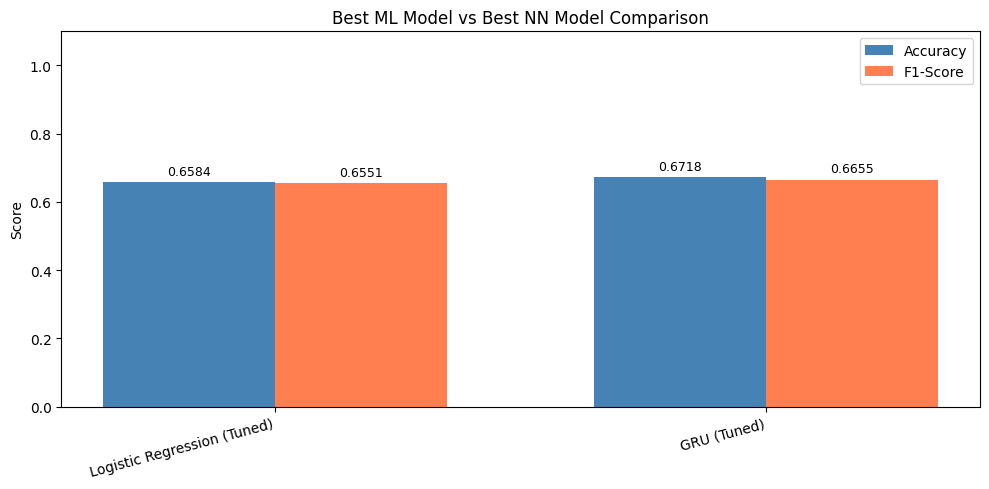

In [ ]:
# Comparison bar chart
comparison_df = pd.DataFrame({
    'Model':  [best_ml, best_nn],
    'Accuracy': [best_ml_acc, best_nn_acc],
    'F1-Score':  [best_ml_f1, best_nn_f1]
})

fig, ax = plt. subplots(figsize=(10, 5))
x = np.arange(2)
width = 0.35

bars1 = ax. bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['F1-Score'], width, label='F1-Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Best ML Model vs Best NN Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar. get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Final Summary

In [ ]:
print("FINAL SUMMARY")

print(f"""
EXPERIMENT SUMMARY:

1. TOTAL MODELS TRAINED: {len(results)}
   - 9 Baseline models
   - 9 Tuned models (after hyperparameter tuning)

2. WORD REPRESENTATIONS USED:
   - TF-IDF (with unigrams and bigrams, max 10,000 features)
   - Skip-gram (Word2Vec, 100-dimensional embeddings)

3. MODELS TRAINED:
   ML Models with TF-IDF:
   - Logistic Regression (Baseline + Tuned)

   DNN with TF-IDF:
   - Deep Neural Network (Baseline + Tuned)

   NN Models with Skip-gram:
   - SimpleRNN, GRU, LSTM (Baseline + Tuned each)
   - Bidirectional SimpleRNN, Bidirectional GRU, Bidirectional LSTM (Baseline + Tuned each)
   - DNN with Skip-gram embeddings (Baseline + Tuned)

4. HYPERPARAMETER TUNING:
   - Each model was tuned separately
   - Validation F1-Score was used to select best hyperparameters
   - Best hyperparameters were then evaluated on test set

5. EVALUATION METRICS:
   - Accuracy
   - F1-Score (Macro)
   - Confusion Matrix
   - Classification Report

6. KEY FINDINGS:
   - Best Overall Model: {best_model}
     * Accuracy: {results[best_model]['accuracy']:.4f}
     * F1-Score:  {results[best_model]['f1_score']:.4f}

   - Worst Overall Model: {worst_model}
     * Accuracy: {results[worst_model]['accuracy']:.4f}
     * F1-Score: {results[worst_model]['f1_score']:.4f}

   - Best ML Model: {best_ml}
   - Best NN Model: {best_nn}

7. CONCLUSIONS:
   - Hyperparameter tuning improved model performance
   - {winner} achieved the best results overall
   - Neural networks with Skip-gram embeddings capture semantic relationships
   - Bidirectional models often outperform unidirectional counterparts
""")

# Display final best model with its hyperparameters
print("\nBEST MODEL DETAILS")
if 'Tuned' in best_model:
    # Find the base model name to get tuning results
    base_name = best_model. replace(' (Tuned)', '').replace(' - Tuned', '')
    if base_name in tuning_results:
        best_params = tuning_results[base_name]['tuned']['params']
        print(f"Model: {best_model}")
        print(f"Best Hyperparameters: {best_params}")
        print(f"Test Accuracy: {results[best_model]['accuracy']:.4f}")
        print(f"Test F1-Score:  {results[best_model]['f1_score']:.4f}")
else:
    print(f"Model: {best_model} (Baseline)")
    print(f"Test Accuracy: {results[best_model]['accuracy']:.4f}")
    print(f"Test F1-Score: {results[best_model]['f1_score']:.4f}")

FINAL SUMMARY

EXPERIMENT SUMMARY:

1. TOTAL MODELS TRAINED: 18
   - 9 Baseline models
   - 9 Tuned models (after hyperparameter tuning)

2. WORD REPRESENTATIONS USED:
   - TF-IDF (with unigrams and bigrams, max 10,000 features)
   - Skip-gram (Word2Vec, 100-dimensional embeddings)

3. MODELS TRAINED:
   ML Models with TF-IDF:
   - Logistic Regression (Baseline + Tuned)

   DNN with TF-IDF:
   - Deep Neural Network (Baseline + Tuned)

   NN Models with Skip-gram:
   - SimpleRNN, GRU, LSTM (Baseline + Tuned each)
   - Bidirectional SimpleRNN, Bidirectional GRU, Bidirectional LSTM (Baseline + Tuned each)
   - DNN with Skip-gram embeddings (Baseline + Tuned)

4. HYPERPARAMETER TUNING:
   - Each model was tuned separately
   - Validation F1-Score was used to select best hyperparameters
   - Best hyperparameters were then evaluated on test set

5. EVALUATION METRICS:
   - Accuracy
   - F1-Score (Macro)
   - Confusion Matrix
   - Classification Report

6. KEY FINDINGS:
   - Best Overall Mode